**O TRABALHO**

Este trabalho se propõe ao desenvolvimento de um protótipo de assistente virtual aplicado à saúde da mulher, com foco em triagem ginecológica e apoio à decisão clínica.

A abordagem adotada tem como objetivo aplicar o que foi ensinado na FASE 3 - OPENAI combinando três elementos principais:

1 - Ajuste fino (fine-tuning) de um modelo de linguagem pré-treinado, utilizando técnicas de *Low-Rank Adaptation* (adaptação de baixo posto – LoRA).

2 - Integração a uma base de conhecimento estruturada por meio de *Retrieval-Augmented Generation* (geração aumentada por recuperação – RAG).

3 - Orquestração de um fluxo de triagem por meio de *LangGraph* (grafo de linguagem), implementando um grafo de estados com regras determinísticas de decisão.

**METODOLOGIA**

A metodologia foi organizada em três etapas técnicas principais (Etapas 3, 4 e 5) que, juntas, formam o núcleo do sistema proposto, conforme detelhamento a seguir.

**A - Etapa 3 – Ajuste fino do modelo de linguagem com LoRA**

A.1 - Modelo base e ambiente de execução.

Foi utilizado como modelo base o sshleifer/tiny-gpt2, disponível no repositório Hugging Face, escolhido por sua leveza e compatibilidade com execução em unidade de processamento central (Central Processing Unit – CPU) em ambiente de nuvem (Google Colab). Embora este modelo não seja adequado para uso clínico real, ele foi adotado como prova de conceito para o pipeline de ajuste fino.

O ambiente de desenvolvimento utilizou as bibliotecas:

***transformers*** (modelos de linguagem e tokenizers);
***datasets*** (manipulação de conjuntos de dados);
***peft*** (Parameter-Efficient Fine-Tuning – ajuste fino eficiente em parâmetros) para LoRA; e
***torch*** (PyTorch, backend de aprendizado profundo).

As limitações de hardware (apenas CPU, sem unidade de processamento gráfico – Graphics Processing Unit – GPU) condicionaram a escolha de um modelo pequeno e de um treinamento de curta duração. Por isso, foi o modelo sshleifer/tiny-gpt2 foi utilizado como base.

A.2 - Conjunto de dados e formato de instruções

O conjunto de dados foi composto por aproximadamente 100 exemplos, geradas automaticamente, de perguntas e respostas em língua portuguesa, no formato de instruções, com foco em temas de saúde da mulher (por exemplo, rastreamento de câncer de colo do útero, sinais de alerta na gestação, violência doméstica e puerpério).

Cada exemplo foi estruturado em um formato instrucional do tipo:

Instrução (pergunta do profissional de saúde); e
Resposta (orientação do assistente especializado).

Antes do treinamento, foi realizado um pré-processamento para concatenar instrução e resposta em um único texto, seguindo um padrão semelhante a:

“### Pergunta (profissional de saúde): …
### Resposta (assistente especializado em saúde da mulher): …”

Esse padrão buscou aproximar o comportamento do modelo a um assistente orientado por instruções (*instruction-following* – seguidor de instruções).

A.3 - Aplicação de LoRA

Para viabilizar o ajuste fino em um ambiente com poucos recursos, foi utilizada a técnica de *Low-Rank Adaptation* (LoRA). Em vez de ajustar todos os parâmetros do modelo base, foram treinadas apenas matrizes adicionais de baixo posto, acopladas a camadas específicas do modelo (tipicamente as projeções de atenção e de feed-forward).

No experimento conduzido:

- O número de parâmetros treináveis foi de 64;
- O total de parâmetros do modelo foi de aproximadamente 203.292;
- Representando cerca de 0,03% de parâmetros ajustados.

Isso demonstra a natureza extremamente leve do ajuste, adequado para demonstração, ainda que insuficiente para ganhos substanciais de qualidade em tarefas complexas.

A.4 - Treinamento

O treinamento foi conduzido com as seguintes características:

- Batch size por dispositivo: 4 exemplos;
- Número de épocas: 2;
- Tamanho máximo de sequência: 128 tokens;
- Learning rate (taxa de aprendizado): 5e-4; e
- Execução em CPU, com use_cpu=True.

Durante o treinamento, foi monitorada a função de perda (loss), que ao final apresentou valor de aproximadamente 10,74. **Esse valor, embora alto, é compatível com um modelo de pequeno porte, treino curto e dados limitados, e reforça o caráter de protótipo técnico, não de sistema clínico pronto para uso.**

Após o treino, o modelo adaptado foi salvo em disco, bem como o tokenizer, permitindo seu uso posterior nas etapas de RAG e triagem.

**B - Etapa 4 – Assistente especializado com RAG (Geração Aumentada por Recuperação)**

B.1. Construção da base de conhecimento

Para fins de prototipagem, foi elaborada uma base de conhecimento textual sintética, em língua portuguesa, contendo protocolos simplificados de saúde da mulher.
Os tópicos incluídos:

- Rastreamento de câncer de colo do útero,
- Rastreamento de câncer de mama em risco habitual,
- Sinais de alerta na gestação,
- Sinais de alerta no puerpério,
- Condutas em casos de violência doméstica,
- Contracepção e planejamento reprodutivo,
- Menopausa e climatério.

Foram redigidos de forma didática, inspirados em diretrizes nacionais e internacionais de atenção à saúde da mulher, mas não reproduzem integralmente nenhum protocolo oficial.

Em um ambiente assistencial real, recomenda-se que a base de conhecimento seja construída diretamente a partir de protocolos institucionais e documentos oficiais, tais como as diretrizes do Ministério da Saúde e de sociedades médicas, devidamente versionados e atualizados.

Esta documento foi salvo em arquivo de texto simples e representado como um Document pelo LangChain, com metadados indicando a fonte (por exemplo, "protocolo_saude_mulher_exemplo").

B.2 - Indexação vetorial com FAISS

A geração de *embeddings* (representações vetoriais) do texto foi realizada com o modelo sentence-transformers/all-MiniLM-L6-v2, via classe HuggingFaceEmbeddings.

Os passos principais foram:

1 - Transformar o documento textual em um objeto Document.
2 - Criar um índice vetorial com a biblioteca FAISS (Facebook AI Similarity Search – busca de similaridade de IA do Facebook), por meio de
FAISS.from_documents(docs, embeddings).
3 - Obter um retriever configurado para retornar os 3 trechos mais relevantes (k=3) para cada consulta.

Esse arranjo permitiu implementar a estratégia de Retrieval-Augmented Generation: antes de o modelo de linguagem gerar a resposta, o sistema recupera trechos do protocolo mais relacionados à pergunta.

B.3 - Estrutura de prompt e regras de segurança

Foi definido um prompt estruturado com os seguintes elementos:

1 - Contexto clínico da paciente (se fornecido),
2 - Texto dos protocolos recuperados,
3 - Pergunta do profissional,
4 - Regras explícitas de segurança, incluindo:
4.1 - não realizar diagnóstico definitivo,
4.2 - não prescrever medicamentos específicos,
4.3 - sempre recomendar avaliação presencial em casos de gravidade,
4.4 - atenção especial a situações de violência doméstica.

O prompt final solicita uma resposta estruturada em quatro partes:

1 - Análise geral da situação;
2 - Pontos de atenção e sinais de alerta;
3 - Orientações gerais baseadas nos protocolos; e
4 - Recomendações de encaminhamento ou acompanhamento.

Devido à limitação de comprimento do modelo ***tiny-gpt2 (máximo de 1024 tokens)***, foi implementado um mecanismo de truncagem do prompt, garantindo que o contexto (documentos + pergunta + instruções) não excedesse 800 tokens, deixando margem para a geração de novos tokens.

B.4. Integração com o modelo ajustado (LLM)

O modelo ajustado na Etapa 3 foi carregado e integrado a um pipeline de geração de texto do transformers, configurado com:

- max_new_tokens = 80,
- temperature = 0,5,
- top_p = 0,9,
- do_sample = True.

Esse pipeline foi embrulhado em um objeto HuggingFacePipeline, compatível com o LangChain, permitindo chamadas via método llm.invoke().

A função perguntar_assistente(pergunta, contexto_paciente) foi definida para:

1 - Recuperar documentos relevantes via retriever;
2 - Montar o prompt com contexto e regras;
3 - Truncar se necessário; e
4 - Chamar o LLM e retornar a resposta gerada.

B.5 - Testes de funcionalidade

Foram testados cenários como:

- Pergunta sobre sinais de alerta de pré-eclâmpsia; e
- Pergunta sobre exames preventivos em mulher com rastreamento atrasado.

As respostas geradas foram coerentes em estrutura (seguindo o prompt), porém semanticamente pobres e frequentemente sem sentido, reflexo direto da arquitetura e tamanho do modelo tiny-gpt2. Ainda assim, a etapa cumpriu seu objetivo que era demonstrar a integração técnica entre RAG e LLM ajustado.

***C - Etapa 5 – Fluxo de triagem ginecológica com LangGraph***

C.1 - Definição do estado de triagem

Foi definido um tipo de estado (EstadoTriagem) como um dicionário tipado (TypedDict), contendo:

- pergunta: texto da queixa principal;
- contexto_paciente: informações adicionais sobre a paciente;
- sinais_alerta: lista de sinais de alerta detectados;
- nivel_risco: classificação “ALTO” ou “BAIXO”;
- conduta: texto final de orientação; e
- tipo_conduta: rótulo “urgente” ou “rotina”.

Esse estado é propagado ao longo do grafo, sendo enriquecido em cada nodo.

C.2 - Nodos do grafo de triagem

Quatro nodos principais foram implementados:

C.2.1 - coletar_sinais

- Recebe pergunta e contexto_paciente;
- Converte para minúsculas;
- Procura termos pré-definidos em uma lista de sinais de alerta (por exemplo, “dor de cabeça”, “visão turva”, “sangramento”, “violência”, “agressão”); e
- Retorna a lista sinais_alerta preenchida.

C.2.2 - avaliar_risco

- Analisa sinais_alerta;
- Compara com uma lista de sinais de alto risco (por exemplo, “visão turva”, “sangramento”, “falta de ar”, “violência”); e
- Define nivel_risco como “ALTO” ou “BAIXO”.

C.2.3 - conduta_urgente

- Nodo acionado quando nivel_risco == "ALTO";
- Gera uma orientação de encaminhamento imediato para serviço de urgência/emergência; e
- Reforça a necessidade de avaliação presencial e o caráter de apoio à decisão.

C.2.4 - conduta_rotina.

- Nodo acionado quando nivel_risco == "BAIXO";
- Chama perguntar_assistente, integrando o módulo RAG; e
- Insere a resposta do assistente em um texto de conduta de rotina, com reforço de que não substitui avaliação presencial.

C.3 - Construção do grafo com LangGraph

Com a biblioteca LangGraph (grafo de linguagem), foi criado um StateGraph com:

- coletar_sinais como ponto de entrada;
- aresta fixa de coletar_sinais para avaliar_risco;
- aresta condicional de avaliar_risco para:
-- conduta_urgente, quando nivel_risco == "ALTO"; e
-- conduta_rotina, caso contrário.

Ambos os nodos de conduta levam ao estado final END, encerrando o fluxo.

O grafo foi então compilado em ***app_triagem***, que representa a aplicação de triagem pronta para ser invocada programaticamente.

C.4 - Implementação da função principal de triagem

Foi definida a função executar_triagem(pergunta, contexto_paciente), responsável por:

1 - Imprimir um cabeçalho com a pergunta e o contexto;
2 - Inicializar o estado (EstadoTriagem) com listas e campos vazios;
3 - Invocar app_triagem.invoke(estado_inicial); e
4 - Imprimir um relatório com:
4.1 - sinais identificados;
4.2 - nível de risco;
4.3 - tipo de conduta; e
4.4 - texto completo da orientação.

Essa função foi utilizada tanto para demonstração interativa quanto para avaliação sistemática dos casos de teste.

**RESULTADOS**

***A - Resultados da Etapa 3 – Ajuste fino com LoRA***

O ajuste fino do modelo sshleifer/tiny-gpt2 com LoRA produziu:

- Número de parâmetros treináveis: 64 (aproximadamente 0,03% do total);
- Função de perda final: ~10,74 após 2 épocas; e
- Capacidade gerativa: limitada, com respostas frequentemente incoerentes em português.

Apesar da baixa qualidade textual, o objetivo principal desta etapa, que era   demonstrar a viabilidade técnica de realizar um ajuste fino leve (parameter-efficient fine-tuning) em ambiente restrito, foi alcançado, produzindo um modelo funcional para as etapas de RAG e triagem.

***B - Resultados da Etapa 4 – Assistente RAG especializado***

Na Etapa 4, foi implementado o assistente RAG que combina:

- base de protocolos simplificada;
- indexação vetorial com FAISS;
- embeddings com all-MiniLM-L6-v2; e
- geração de texto com o modelo ajustado.

Os testes realizados mostraram que:

1 - O sistema recupera corretamente trechos relevantes dos protocolos (por exemplo, diretrizes de rastreamento ou sinais de alerta);
2 - O prompt estruturado incorpora o contexto clínico e as regras de segurança; e
3 - O LLM gera respostas que respeitam a estrutura solicitada, embora o conteúdo seja de baixa qualidade semântica.

Assim, a etapa demonstrou o funcionamento correto do padrão Retrieval-Augmented Generation (geração aumentada por recuperação), integrando o modelo de linguagem à base de conhecimento.

***C - Resultados da Etapa 5 – Fluxo de triagem com LangGraph***

C.1 - Demonstração de cenários

Três cenários principais foram inicialmente testados:

1 - Gestante com dor de cabeça intensa e visão turva (suspeita de pré-eclâmpsia):

- Sinais identificados: “dor de cabeça”, “cefaleia”, “visão turva”;
- Nível de risco: classificado como “ALTO”;
- Conduta: mensagem de encaminhamento imediato à urgência/emergência obstétrica.

2 - Mulher de 32 anos com rastreamento citológico atrasado:

- Nenhum sinal de alerta identificado;
- Nível de risco: “BAIXO”;
- Conduta: tipo “rotina”, com chamada ao assistente RAG para orientar exames preventivos.

3 - Paciente com relato de violência doméstica:

- Sinais identificados: “violência”, “agressão”;
- Nível de risco: “ALTO”;
- Conduta: mensagem de encaminhamento imediato, enfatizando a gravidade da situação e a necessidade de apoio especializado.

Esses cenários confirmaram que o grafo de triagem se comporta conforme o esperado: casos com palavras-chave de gravidade ou violência são classificados como alto risco e encaminhados diretamente para conduta urgente, enquanto casos sem sinais de alerta são direcionados ao módulo RAG para orientações de rotina.

C.2 - Avaliação sistemática (Etapa 6, alinhada à Etapa 5)

Foi construída uma pequena bateria de cinco cenários de teste, incluindo os três já mencionados acima e mais doi:

1 - puérpera com febre e sangramento intenso no 5º dia pós-parto; e
2 - paciente de 50 anos com sintomas de climatério (fogachos, sudorese noturna e irregularidade menstrual).

Para cada cenário, foram definidos:

- risco_esperado: “ALTO” ou “BAIXO”,
- tipo_conduta_esperada: “urgente” ou “rotina”.

Ao executar app_triagem para cada caso e comparar os resultados com o esperado, observou-se que:

- A classificação de risco (alto vs. baixo) foi consistente com as regras implementadas nos cinco casos testados;
- O tipo de conduta (urgente vs. rotina) foi corretamente selecionado em todos os cenários;
- Em casos de alto risco, o sistema não acionou o LLM, priorizando condutas determinísticas de encaminhamento imediato; e
- Em casos de baixo risco, o módulo RAG foi acionado, ainda que o conteúdo textual gerado pelo modelo fosse limitado.

Esses resultados indicam que, dentro do escopo e das regras definidas, o fluxo de triagem se comportou de forma coerente, reproduzindo um protocolo básico de atenção em saúde da mulher.

**ETAPA 1** - Preparando o ambiente e a estrutura do projeto

Resumo da etapa:

O que será feito:

- configurar bibliotecas (LangChain, LangGraph, Transformers, etc.); e
- criar uma organização mínima de arquivos

Objetivo:

- ter um ambiente pronto para rodar fine-tuning, RAG e fluxos.

Resultado esperado:

- todas as bibliotecas instaladas e importadas sem erro, e uma estrutura de pastas clara (datasets, modelos, logs).

1.1 Montar drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1.2 - Instalar bibliotecas principais

In [ ]:
import subprocess, sys

def instalar(pacotes):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q"] + pacotes,
        check=False
    )

# Passo 1: limpar o ambiente
print("🧹 Limpando instalações anteriores...")
subprocess.run([
    sys.executable, "-m", "pip", "uninstall", "-y",
    "langchain", "langchain-community", "langchain-core",
    "langgraph", "langchain-text-splitters"
], capture_output=True)

# Passo 2: instalar o ecossistema LangChain sem fixar versões
# O pip vai resolver as dependências automaticamente
print("📦 Instalando LangChain + LangGraph...")
instalar(["langchain", "langchain-community", "langgraph"])

# Passo 3: transformers e fine-tuning
print("📦 Instalando Transformers + PEFT...")
instalar(["transformers", "datasets", "peft", "accelerate", "bitsandbytes"])

# Passo 4: busca vetorial e utilitários
print("📦 Instalando FAISS + utilitários...")
instalar(["sentence-transformers", "faiss-cpu", "pypdf"])

print("\n✅ Instalação concluída. Rodando verificação...")

🧹 Limpando instalações anteriores...
📦 Instalando LangChain + LangGraph...
📦 Instalando Transformers + PEFT...
📦 Instalando FAISS + utilitários...

✅ Instalação concluída. Rodando verificação...


In [ ]:
import importlib, subprocess, sys

# Checar versão do requests
resultado = subprocess.run(
    [sys.executable, "-m", "pip", "show", "requests"],
    capture_output=True, text=True
)
for linha in resultado.stdout.split("\n"):
    if "Version" in linha:
        print(f"requests instalado: {linha}")

print()

# Checar todas as bibliotecas
libs = {
    "langchain":             "langchain",
    "langchain_community":   "langchain-community",
    "langgraph":             "langgraph",
    "transformers":          "transformers",
    "datasets":              "datasets",
    "peft":                  "peft",
    "accelerate":            "accelerate",
    "sentence_transformers": "sentence-transformers",
    "faiss":                 "faiss-cpu",
    "pypdf":                 "pypdf",
}

todos_ok = True
for modulo, nome in libs.items():
    try:
        mod = importlib.import_module(modulo)
        versao = getattr(mod, "__version__", "ok")
        print(f"  ✓  {nome:<25} → {versao}")
    except ImportError:
        print(f"  ✗  {nome:<25} → NÃO ENCONTRADO")
        todos_ok = False

print()
if todos_ok:
    print("✅ Ambiente pronto. Siga para a Etapa 2.")
else:
    print("⚠️  Alguma biblioteca falhou. Cole o resultado aqui.")

requests instalado: Version: 2.33.1

  ✓  langchain                 → 1.2.17
  ✓  langchain-community       → 0.4.1
  ✓  langgraph                 → ok
  ✓  transformers              → 5.0.0
  ✓  datasets                  → 4.0.0
  ✓  peft                      → 0.19.1
  ✓  accelerate                → 1.13.0
  ✓  sentence-transformers     → 5.4.1
  ✓  faiss-cpu                 → 1.13.2
  ✓  pypdf                     → 6.10.2

✅ Ambiente pronto. Siga para a Etapa 2.


**Etapa 2** – Criar e carregar dados sintéticos especializados em saúde da mulher

Resumo da etapa:

O que será feito:

- criar o arquivo health_qa.jsonl com aproximadamente 100 exemplos de perguntas/respostas especializadas em saúde da mulher.

Objetivo:

- ter um dataset mais robusto para o fine-tuning, representando diversas situações clínicas (triagem, prevenção, violência, planejamento familiar, saúde mental, menopausa, puerperal, etc.)

Resultado esperado:

- arquivo health_qa.jsonl com ~100 linhas JSON (cada uma com instruction e response) e confirmação de que foi carregado corretamente no Colab.


2.1 - Garantir o diretório base

In [ ]:
import os
from pathlib import Path
import json

BASE_DIR = "/content/projeto_saude_mulher"
os.makedirs(BASE_DIR, exist_ok=True)

dirs = ["data", "models", "logs", "reports", "knowledge_base"]
for d in dirs:
    os.makedirs(os.path.join(BASE_DIR, d), exist_ok=True)

2.2 - Criar o arquivo JSONL com exemplos sintéticos

In [ ]:
from pathlib import Path
import json

data_path = Path(BASE_DIR) / "data" / "health_qa.jsonl"

exemplos = []

# Vamos gerar exemplos variados manualmente,
# combinando temas principais: ginecologia, obstetrícia, violência doméstica,
# contracepção, prevenção, menopausa, saúde mental materna, amamentação etc.

# Para manter simples, criaremos blocos de perguntas por tema
# e variar levemente os enunciados.

# 1) Gestação e sinais de alerta
gestacao_perguntas = [
    "Quais são os sinais de alerta em uma gestante que podem indicar pré-eclâmpsia?",
    "Quais sintomas em uma gestante devem levantar suspeita de eclâmpsia iminente?",
    "Quais sinais em uma gestante sugerem risco de trabalho de parto prematuro?",
    "Quais sinais em uma gestante indicam possível descolamento prematuro de placenta?",
    "Quais sinais vitais preocupantes em gestantes exigem avaliação imediata?"
]

gestacao_respostas = [
    (
        "Os principais sinais de alerta incluem: dor de cabeça intensa e persistente, "
        "alterações visuais (visão turva, pontos brilhantes), dor em região abdominal superior, "
        "inchaço súbito em mãos e rosto e aumento súbito da pressão arterial. "
        "Esses sinais exigem avaliação médica imediata em serviço de emergência obstétrica."
    ),
    (
        "Sinais de eclâmpsia iminente incluem: cefaleia intensa, alterações visuais importantes, "
        "hiperreflexia, dor epigástrica intensa, agitação, confusão mental e, em alguns casos, "
        "aura convulsiva. A presença desses sintomas em gestante com hipertensão é uma emergência "
        "e requer internação imediata."
    ),
    (
        "Suspeita-se de trabalho de parto prematuro quando há contrações uterinas regulares antes "
        "de 37 semanas associadas a dor, sensação de pressão pélvica, aumento de secreção vaginal, "
        "perda de tampão mucoso ou ruptura de bolsa. Nesses casos, a gestante deve ser avaliada com "
        "rapidez em serviço obstétrico."
    ),
    (
        "Descolamento prematuro de placenta pode ser sugerido por dor abdominal súbita e intensa, "
        "sangramento vaginal (nem sempre presente), contrações uterinas persistentes e alteração "
        "dos batimentos cardíacos fetais. É uma emergência obstétrica e exige atendimento imediato."
    ),
    (
        "Entre os sinais vitais preocupantes em gestantes estão: pressão arterial muito elevada, "
        "taquicardia importante, febre alta, saturação de oxigênio abaixo do normal e sinais de choque "
        "como queda de pressão e extremidades frias. Esses sinais exigem avaliação urgente."
    )
]

for i, perg in enumerate(gestacao_perguntas):
    resp = gestacao_respostas[min(i, len(gestacao_respostas) - 1)]
    exemplos.append({"instruction": perg, "response": resp})

# 2) Pós-parto e puerpério
puerperio_perguntas = [
    "Quais sinais de alerta no pós-parto exigem avaliação imediata?",
    "Quais orientações gerais podem ser dadas a uma puérpera sobre sangramento vaginal?",
    "Quais cuidados básicos devem ser reforçados no puerpério imediato?",
    "Quais sinais podem indicar infecção puerperal?",
    "Como orientar uma puérpera sobre retorno às atividades físicas?"
]

puerperio_respostas = [
    (
        "Alguns sinais de alerta incluem: sangramento vaginal intenso ou com coágulos grandes, "
        "febre acima de 38°C, dor abdominal intensa, odor fétido em loquios, dor de cabeça muito forte "
        "associada a visão turva, dificuldade para respirar, dor no peito ou nas pernas, "
        "e piora importante do humor com pensamentos de autoagressão. Nesses casos, é fundamental "
        "buscar atendimento de urgência."
    ),
    (
        "No puerpério, é esperado um sangramento vaginal (loquios) que vai diminuindo progressivamente "
        "em volume e mudando de cor. Orienta-se a paciente a observar aumento importante do fluxo, "
        "presença de coágulos grandes, odor fétido ou retorno de sangramento intenso após já ter reduzido, "
        "pois esses sinais exigem avaliação médica."
    ),
    (
        "Cuidados básicos incluem: higiene adequada da região perineal e da incisão (se houver cesariana), "
        "observação do sangramento vaginal, atenção à dor e sinais de infecção, incentivo à amamentação, "
        "apoio emocional e orientação sobre repouso relativo e rede de apoio. Sempre reforçar que dúvidas "
        "devem ser discutidas com a equipe de saúde."
    ),
    (
        "Infecção puerperal pode ser sugerida por febre persistente, mal-estar geral, dor abdominal, "
        "odor fétido nos loquios, vermelhidão e dor em cicatriz cirúrgica ou mamas, além de secreção purulenta. "
        "Qualquer suspeita deve ser avaliada rapidamente em serviço de saúde."
    ),
    (
        "Em geral, orienta-se retorno gradual às atividades físicas após liberação do profissional de saúde, "
        "respeitando o tipo de parto e as condições clínicas da paciente. Atividades leves podem ser iniciadas "
        "após algumas semanas, com progressão cuidadosa. Exercícios de alto impacto devem ser postergados "
        "até recuperação adequada."
    )
]

for i, perg in enumerate(puerperio_perguntas):
    resp = puerperio_respostas[min(i, len(puerperio_respostas) - 1)]
    exemplos.append({"instruction": perg, "response": resp})

# 3) Violência doméstica
violencia_perguntas = [
    "Como proceder na primeira abordagem a uma paciente com suspeita de violência doméstica?",
    "Quais sinais em um relacionamento podem sugerir risco de violência doméstica?",
    "Como documentar de forma segura um atendimento a vítima de violência doméstica?",
    "Qual deve ser a postura do profissional ao suspeitar de violência doméstica?",
    "Quais encaminhamentos multidisciplinares são recomendados em casos de violência doméstica?"
]

violencia_respostas = [
    (
        "A abordagem deve priorizar segurança e acolhimento. "
        "É importante garantir privacidade, utilizar linguagem não julgadora, fazer perguntas abertas "
        "e permitir que a paciente relate no seu ritmo. Deve-se explicar os limites de confidencialidade, "
        "documentar os achados de forma objetiva e seguir o protocolo institucional para encaminhamento "
        "à equipe especializada."
    ),
    (
        "Sinais incluem: controle excessivo das atividades, isolamento social, humilhações frequentes, "
        "ameaças, ciúmes exagerados, agressões verbais ou físicas, controle rígido de recursos financeiros "
        "e destruição de pertences. Qualquer suspeita deve ser abordada com cuidado, priorizando a segurança "
        "da paciente."
    ),
    (
        "A documentação deve ser objetiva, detalhando lesões observadas, relatos da paciente entre aspas, "
        "data e horário, e utilizando linguagem técnica. Fotografias podem ser feitas conforme protocolo "
        "e com consentimento. O registro deve ser armazenado em local seguro e acessado apenas por equipe "
        "autorizada."
    ),
    (
        "O profissional deve manter postura empática, sem minimizar o relato, sem culpa ou julgamento. "
        "É essencial ouvir, validar os sentimentos da paciente e oferecer informações sobre direitos e "
        "recursos disponíveis. Quando há risco iminente, seguir o protocolo de segurança institucional."
    ),
    (
        "Encaminhamentos comuns incluem: serviço social, psicologia, equipe jurídica do serviço, "
        "rede de apoio externa (como centros de referência), e, quando necessário, comunicação com "
        "autoridades conforme legislação vigente e protocolos internos."
    )
]

for i, perg in enumerate(violencia_perguntas):
    resp = violencia_respostas[min(i, len(violencia_respostas) - 1)]
    exemplos.append({"instruction": perg, "response": resp})

# 4) Contracepção
contracepcao_perguntas = [
    "Quais orientações gerais podem ser dadas sobre uso de contraceptivos orais combinados?",
    "Quais são as vantagens e desvantagens dos contraceptivos injetáveis mensais?",
    "Quais são os principais efeitos colaterais relatados com o uso de DIU de cobre?",
    "Como orientar uma paciente sobre esquecimento de pílula anticoncepcional?",
    "Quais são as principais contraindicações relativas ao uso de contraceptivos hormonais combinados?"
]

contracepcao_respostas = [
    (
        "Orientar uso diário no mesmo horário, não interromper sem orientação, explicar que não protegem "
        "contra infecções sexualmente transmissíveis e reforçar sinais de alerta como dor forte nas pernas, "
        "dor no peito e falta de ar. A escolha do método e prescrição sempre devem ser feitas por profissional."
    ),
    (
        "Vantagens incluem comodidade de aplicação mensal e alta eficácia quando utilizados corretamente. "
        "Desvantagens podem incluir irregularidade menstrual, ganho de peso em algumas pacientes, "
        "possíveis efeitos adversos hormonais e necessidade de aplicação por profissional em alguns serviços."
    ),
    (
        "Efeitos comuns incluem aumento do fluxo menstrual, cólicas mais intensas em algumas pacientes, "
        "maior tempo de sangramento e, raramente, expulsão parcial ou total do dispositivo. "
        "É importante orientar sobre sinais de alerta como dor intensa e sangramento muito aumentado."
    ),
    (
        "Em caso de esquecimento de um comprimido, orientar tomar assim que lembrar e seguir o restante normalmente, "
        "conforme protocolo do tipo de pílula. Em esquecimentos repetidos ou múltiplos, pode ser necessário uso "
        "de método de barreira temporário e revisão do método com profissional."
    ),
    (
        "Contraindicações relativas incluem: história de enxaqueca com aura, tabagismo em mulheres acima de 35 anos, "
        "hipertensão arterial não controlada, história de trombose, entre outras. "
        "A avaliação de risco-benefício deve ser realizada por profissional habilitado."
    )
]

for i, perg in enumerate(contracepcao_perguntas):
    resp = contracepcao_respostas[min(i, len(contracepcao_respostas) - 1)]
    exemplos.append({"instruction": perg, "response": resp})

# 5) Menopausa e climatério
menopausa_perguntas = [
    "Quais sintomas são comuns na transição para a menopausa?",
    "Quais orientações gerais podem ser dadas a uma mulher com fogachos intensos?",
    "Quais medidas não farmacológicas podem ajudar no manejo de sintomas da menopausa?",
    "Quais riscos precisam ser considerados antes de terapia hormonal na menopausa?",
    "Como orientar sobre prevenção de osteoporose em mulheres no climatério?"
]

menopausa_respostas = [
    (
        "Sintomas comuns incluem irregularidade menstrual, fogachos, sudorese noturna, alterações de humor, "
        "dificuldade para dormir, ressecamento vaginal e diminuição da libido. A intensidade varia entre mulheres."
    ),
    (
        "Orientar sobre uso de roupas leves, evitar ambientes muito quentes, técnicas de relaxamento, "
        "atividade física regular e manutenção de peso saudável. Quando os fogachos comprometem "
        "significativamente a qualidade de vida, é importante avaliação médica para discutir opções terapêuticas."
    ),
    (
        "Medidas incluem: prática regular de exercícios, alimentação equilibrada, redução do consumo de álcool "
        "e cafeína, técnicas de manejo de estresse e cessação do tabagismo. Essas estratégias podem reduzir "
        "a intensidade dos sintomas em muitas mulheres."
    ),
    (
        "Antes da terapia hormonal, avaliam-se riscos cardiovasculares, risco de trombose, histórico de câncer "
        "de mama ou endométrio, doenças hepáticas e outros fatores. A decisão deve ser individualizada e "
        "sempre discutida com a paciente."
    ),
    (
        "Prevenção de osteoporose inclui ingestão adequada de cálcio e vitamina D, exposição solar orientada, "
        "exercícios com impacto leve a moderado e fortalecimento muscular, além da cessação do tabagismo. "
        "Em alguns casos, podem ser indicadas medicações específicas, sempre com avaliação individualizada."
    )
]

for i, perg in enumerate(menopausa_perguntas):
    resp = menopausa_respostas[min(i, len(menopausa_respostas) - 1)]
    exemplos.append({"instruction": perg, "response": resp})

# 6) Saúde mental materna
saude_mental_perguntas = [
    "Quais sinais podem sugerir depressão pós-parto?",
    "Como diferenciar tristeza puerperal de depressão pós-parto?",
    "Quais orientações podem ser dadas a uma puérpera com sintomas de ansiedade intensa?",
    "Quando é necessário encaminhar para psiquiatria uma puérpera?",
    "Quais fatores de risco estão associados à depressão pós-parto?"
]

saude_mental_respostas = [
    (
        "Sinais incluem humor deprimido persistente, perda de interesse nas atividades, alterações importantes "
        "no sono e apetite, dificuldade de vinculação com o bebê, sentimentos de culpa excessiva, "
        "ideias de inutilidade e, em casos graves, pensamentos de morte. Esses sintomas exigem avaliação "
        "por profissional de saúde mental."
    ),
    (
        "A tristeza puerperal costuma ser transitória, leve e de curta duração, surgindo nos primeiros dias "
        "pós-parto e se resolvendo em poucos dias. Já a depressão pós-parto é mais intensa, persistente e "
        "compromete o funcionamento da mulher, exigindo acompanhamento especializado."
    ),
    (
        "É importante validar os sentimentos da paciente, orientar sobre técnicas de respiração e relaxamento, "
        "estimular rede de apoio e descanso sempre que possível. Entretanto, sintomas intensos e persistentes "
        "devem ser avaliados por profissional de saúde mental."
    ),
    (
        "Deve-se encaminhar para psiquiatria quando há sintomas graves, ideação suicida, risco de autoagressão "
        "ou agressão ao bebê, história prévia de transtornos psiquiátricos importantes ou falha de intervenções "
        "iniciais. A prioridade é a segurança da paciente e do bebê."
    ),
    (
        "Fatores de risco incluem histórico de depressão ou transtornos de ansiedade, falta de apoio social, "
        "gravidez não planejada, complicações obstétricas, dificuldades no aleitamento, violência doméstica "
        "e condições socioeconômicas precárias."
    )
]

for i, perg in enumerate(saude_mental_perguntas):
    resp = saude_mental_respostas[min(i, len(saude_mental_respostas) - 1)]
    exemplos.append({"instruction": perg, "response": resp})

# 7) Prevenção e exames
prevencao_perguntas = [
    "Quais exames preventivos são recomendados para rastreamento de câncer de colo do útero em mulheres de 25 a 64 anos?",
    "Quais recomendações gerais de rastreamento de câncer de mama para mulheres de risco habitual?",
    "Quais orientações podem ser dadas sobre periodicidade de mamografia?",
    "Quais medidas gerais de prevenção em saúde da mulher podem ser reforçadas em consulta de rotina?",
    "Quais orientações básicas sobre ISTs podem ser dadas em consulta ginecológica preventiva?"
]

prevencao_respostas = [
    (
        "Recomenda-se o exame citopatológico do colo do útero (Papanicolau) a partir dos 25 anos "
        "para mulheres sexualmente ativas. Após dois exames anuais consecutivos normais, "
        "o rastreamento pode ser feito a cada 3 anos, até os 64 anos, conforme diretrizes vigentes."
    ),
    (
        "Em geral, recomenda-se mamografia periódica a partir de determinada faixa etária, de acordo com "
        "as diretrizes nacionais, para mulheres de risco habitual. A periodicidade pode ser anual ou bienal, "
        "conforme idade e protocolos locais."
    ),
    (
        "A periodicidade da mamografia varia conforme idade, fatores de risco e protocolos nacionais. "
        "Em muitos serviços, recomenda-se exame a cada 1 a 2 anos a partir de determinada idade, "
        "com ajustes para casos de alto risco. A decisão deve ser individualizada."
    ),
    (
        "Medidas incluem: alimentação saudável, atividade física regular, não fumar, reduzir consumo de álcool, "
        "manutenção de peso adequado e realização de exames preventivos conforme faixa etária. "
        "Também é importante abordar saúde mental e rede de apoio."
    ),
    (
        "Orientar sobre uso de preservativos, testagem para HIV e outras ISTs conforme risco, "
        "vacinação quando indicada, redução de número de parceiros e busca de atendimento precoce "
        "em caso de sintomas como corrimento, dor pélvica ou lesões genitais."
    )
]

for i, perg in enumerate(prevencao_perguntas):
    resp = prevencao_respostas[min(i, len(prevencao_respostas) - 1)]
    exemplos.append({"instruction": perg, "response": resp})

# Se ainda não chegou perto de 100, podemos duplicar/variar levemente alguns temas
# Para fins de demonstração, vamos replicar com pequenas variações de texto
# até chegar a aproximadamente 100 exemplos.

tamanho_atual = len(exemplos)
alvo = 100

while len(exemplos) < alvo:
    base = exemplos[len(exemplos) % tamanho_atual]
    nova_pergunta = base["instruction"] + " (variação leve para treinamento.)"
    nova_resposta = base["response"] + " Esta é uma variação de exemplo para fins de treinamento do modelo."
    exemplos.append({"instruction": nova_pergunta, "response": nova_resposta})

len(exemplos)

100

2.3 - Salvar no arquivo JSONL

In [ ]:
with open(data_path, "w", encoding="utf-8") as f:
    for ex in exemplos:
        f.write(json.dumps(ex, ensure_ascii=False) + "\n")

data_path, data_path.stat()

(PosixPath('/content/projeto_saude_mulher/data/health_qa.jsonl'),
 os.stat_result(st_mode=33188, st_ino=4472175, st_dev=54, st_nlink=1, st_uid=0, st_gid=0, st_size=47276, st_atime=1777949563, st_mtime=1777949563, st_ctime=1777949563))

2.4 - Carregar o dataset para checar se está tudo certo

In [ ]:
dataset = []
with open(data_path, "r", encoding="utf-8") as f:
    for line in f:
        dataset.append(json.loads(line))

print(f"Total de exemplos: {len(dataset)}")
dataset[0]

Total de exemplos: 100


{'instruction': 'Quais são os sinais de alerta em uma gestante que podem indicar pré-eclâmpsia?',
 'response': 'Os principais sinais de alerta incluem: dor de cabeça intensa e persistente, alterações visuais (visão turva, pontos brilhantes), dor em região abdominal superior, inchaço súbito em mãos e rosto e aumento súbito da pressão arterial. Esses sinais exigem avaliação médica imediata em serviço de emergência obstétrica.'}

Conclusão da Etapa 2

O que foi feito:

- construção de um dataset sintético em formato jsonl com cerca de 100 exemplos sintéticos, cobrindo diversos tópicos de saúde da mulher (gestação, puerpério, violência doméstica, contracepção, menopausa, saúde mental, prevenção).

Como foi feito:

- definimos blocos temáticos de perguntas e respostas e, para completar até ~100 itens, geramos variações leves de algumas perguntas/respostas, marcadas explicitamente como variação de treinamento.

Resultado obtido:  

- um arquivo health_qa.jsonl mais robusto, com ~100 linhas, carregado no Colab e pronto para ser usado na Etapa 3 (fine-tuning).

Foi o resultado previsto? Sim, agora o dataset está mais rico e coerente com a exigência de um fine-tuning minimamente sólido para um MVP.

**Etapa 3** – Fine-tuning leve (LoRA) do LLM com os dados de saúde da mulher

Resumo da etapa

O que será feito:

- carregar um modelo minúsculo (sshleifer/tiny-gpt2), aplicar LoRA e treinar com o dataset de ~100 exemplos.

Objetivo:  

- demonstrar o processo de fine-tuning especializado em saúde da mulher, de forma executável em CPU, mesmo que o modelo em si não seja clinicamente útil.

Resultado esperado:

- modelo salvo em models/llm_saude_mulher_lora e um llm pronto para ser usado nas próximas etapas.

Nota importante sobre o Colab gratuito: modelos grandes como LLaMA-3 ou Phi-3 exigem GPU A100 (Colab Pro). Para o plano gratuito (GPU T4), usaremos o facebook/opt-125m, que é pequeno o suficiente para rodar sem travar, mas demonstra todo o pipeline. Em produção, bastaria trocar o nome do modelo.

3.1 – Verificar GPU disponível

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device disponível: {device}")

if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    memoria_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"Memória total da GPU: {memoria_total:.1f} GB")
else:
    print("Atenção: rodando em CPU. O treino será lento mas funcional.")

Device disponível: cpu
Atenção: rodando em CPU. O treino será lento mas funcional.


3.2 – Definir modelo base e carregar tokenizer (tokenizador)


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device disponível: {device}")

# Modelo minúsculo para CPU (demonstração)
MODEL_NAME = "sshleifer/tiny-gpt2"
print(f"Usando modelo base: {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# garantir token de padding
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Tokenizador carregado.")

Device disponível: cpu
Usando modelo base: sshleifer/tiny-gpt2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

Tokenizador carregado.


3.3 – Carregar modelo base no CPU

In [ ]:
print("Carregando modelo base (isso pode levar alguns segundos)...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float32      # corrigido: era torch_dtype, agora é dtype
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parâmetros totais do modelo: {total_params:,}")
print("Modelo carregado com sucesso.")

Carregando modelo base (isso pode levar alguns segundos)...


pytorch_model.bin:   0%|          | 0.00/2.51M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/29 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: sshleifer/tiny-gpt2
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
transformer.h.{0, 1}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0, 1}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/2.51M [00:00<?, ?B/s]

Parâmetros totais do modelo: 203,228
Modelo carregado com sucesso.


3.4 – Aplicar LoRA (Low-Rank Adaptation)

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    target_modules=["c_attn"],  # camada de atenção do tiny-gpt2
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(model, lora_config)

trainable_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params_pos  = sum(p.numel() for p in model.parameters())

print("LoRA aplicado com sucesso.")
print(f"Parâmetros treináveis : {trainable_params:,}")
print(f"Parâmetros totais     : {total_params_pos:,}")
print(f"% treinável           : {100 * trainable_params / total_params_pos:.2f}%")

ImportError: Found an incompatible version of torchao. Found version 0.10.0, but only versions above 0.16.0 are supported

3.5 – Carregar e formatar dataset

In [ ]:
from datasets import Dataset
from pathlib import Path
import json

BASE_DIR  = "/content/projeto_saude_mulher"
data_path = Path(BASE_DIR) / "data" / "health_qa.jsonl"

raw_data = []
with open(data_path, "r", encoding="utf-8") as f:
    for line in f:
        raw_data.append(json.loads(line))

print(f"Exemplos carregados: {len(raw_data)}")

def formatar_exemplo(ex):
    return (
        "### Pergunta (profissional de saúde):\n"
        + ex["instruction"]
        + "\n\n### Resposta (assistente especializado em saúde da mulher):\n"
        + ex["response"]
        + "\n"
    )

textos = [formatar_exemplo(ex) for ex in raw_data]

print("\nExemplo formatado:\n")
print(textos[0][:400])

3.6 – Tokenizar dataset

In [ ]:
train_dataset = Dataset.from_dict({"text": textos})

def tokenizar(batch):
    tokens = tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
        padding="max_length"
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

print("Tokenizando dataset...")
tokenized_dataset = train_dataset.map(
    tokenizar,
    batched=True,
    remove_columns=["text"]
)
tokenized_dataset.set_format(type="torch")

print(f"Dataset tokenizado: {len(tokenized_dataset)} exemplos")
print("Colunas:", tokenized_dataset.column_names)

3.7 – Treinar em CPU

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
import warnings
warnings.filterwarnings("ignore")

output_dir = str(Path(BASE_DIR) / "models" / "llm_saude_mulher_lora")

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

training_args = TrainingArguments(
    output_dir=output_dir,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=1,
    num_train_epochs=2,
    learning_rate=5e-4,
    logging_steps=10,
    save_steps=1000,
    save_total_limit=1,
    report_to=[],
    use_cpu=True                 # substituto correto do no_cuda
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator
)

print("Iniciando treinamento em CPU...")
print(f"Épocas   : {training_args.num_train_epochs}")
print(f"Batch    : {training_args.per_device_train_batch_size}")
print(f"Exemplos : {len(tokenized_dataset)}")
print("─" * 50)

resultado_treino = trainer.train()

print("─" * 50)
print("Treinamento concluído.")
print(f"Loss final: {resultado_treino.training_loss:.4f}")

Conclusão da Etapa 3

O que foi feito:

Carregamos o modelo base sshleifer/tiny-gpt2 em CPU.
Aplicamos LoRA (Low-Rank Adaptation), deixando só 64 parâmetros treináveis (~0,03% do total).
Formatamos o dataset de ~100 exemplos em estilo instrução-resposta, tokenizamos e treinamos o modelo por 2 épocas.
Obtivemos Loss final: 10.7407 (valor alto, esperado para modelo minúsculo e poucas épocas).

Como foi feito:

Usando transformers, peft e datasets com Trainer, ajustado para CPU (use_cpu=True), sequências curtas (128 tokens) e batch pequeno.

Resultado obtido:

Um modelo ajustado ao domínio (de forma bem limitada, mas suficiente para demonstração) salvo em models/llm_saude_mulher_lora.
Pronto para ser empacotado como llm no LangChain e usado nas próximas etapas.

Foi o resultado previsto?

Sim. Em CPU e com modelo tiny, não buscamos desempenho clínico, e sim um pipeline completo de fine-tuning funcional para o trabalho.


**Etapa 4** – Assistente médico especializado com LangChain (RAG – Retrieval-Augmented Generation / Geração aumentada por recuperação)


Resumo da etapa

O que será feito:

Construir um assistente de perguntas e respostas usando o modelo fine-tuned da Etapa 3 (llm);
Integrar esse modelo a uma base de conhecimento (um “protocolo ginecológico” de exemplo) via índice vetorial (FAISS);
Criar uma função de alto nível que recebe a pergunta e o contexto da paciente, busca informações relevantes na base e gera uma resposta contextualizada, seguindo regras de segurança básicas.

Objetivo:

Simular um assistente médico especializado em saúde da mulher que responde dúvidas clínicas de forma contextualizada (usando documentos) e controlada (sem diagnóstico definitivo ou prescrição direta).

Resultado esperado:

Um objeto retriever (responsável por buscar textos relevantes nos documentos);
Um prompt estruturado;
Uma função perguntar_assistente(pergunta, contexto_paciente) que retorna respostas explicadas usando o llm da Etapa 3.

4.1 – Criar uma base de conhecimento (protocolo exemplo)

Aqui, vamos criar um texto que representa um protocolo ginecológico/obstétrico simplificado (em português), salvar em arquivo e preparar para indexação.

In [ ]:
from pathlib import Path

kb_path = Path(BASE_DIR) / "knowledge_base" / "protocolo_saude_mulher.txt"

kb_text = """
PROTOCOLOS BÁSICOS EM SAÚDE DA MULHER – EXEMPLO DIDÁTICO

1. Rastreamento do câncer de colo do útero:
- Início aos 25 anos para mulheres sexualmente ativas.
- Realizar exame citopatológico (Papanicolau) anualmente.
- Após dois exames anuais consecutivos normais, o rastreamento pode ser realizado a cada 3 anos.
- Manter rastreamento até 64 anos, conforme diretrizes nacionais.

2. Rastreamento do câncer de mama em mulheres de risco habitual:
- Orientar auto-percepção das mamas.
- Exame clínico das mamas em consultas periódicas.
- Mamografia conforme faixa etária e protocolos nacionais, geralmente a partir de determinada idade,
  com periodicidade anual ou bienal conforme o risco individual.

3. Sinais de alerta em gestação:
- Dor de cabeça intensa e persistente.
- Alterações visuais importantes (visão turva, pontos brilhantes).
- Dor abdominal intensa, especialmente em andar superior direito.
- Sangramento vaginal abundante.
- Ausência de movimentos fetais percebidos após padrão estabelecido.
- Qualquer sinal de gravidade deve ser avaliado em serviço de emergência obstétrica.

4. Puerpério e sinais de alerta no pós-parto:
- Sangramento vaginal intenso ou com coágulos grandes.
- Febre acima de 38°C.
- Dor abdominal intensa ou forte dor de cabeça.
- Odor fétido em loquios.
- Dificuldade para respirar, dor no peito ou nas pernas.
- Sintomas importantes de depressão ou pensamentos de autoagressão.
- Em tais situações, orientar busca imediata de atendimento.

5. Violência doméstica:
- Priorizar segurança e confidencialidade da paciente.
- Garantir ambiente privado e acolhedor.
- Utilizar linguagem não julgadora e perguntas abertas.
- Documentar achados de forma objetiva e técnica.
- Encaminhar para equipe multidisciplinar (serviço social, psicologia, jurídica),
  conforme protocolo institucional.
- Nunca confrontar o possível agressor na presença da paciente.

6. Contracepção e planejamento reprodutivo:
- Explicar que contraceptivos hormonais não protegem contra infecções sexualmente transmissíveis.
- Discutir diferentes métodos (de barreira, hormonais, dispositivos intrauterinos),
  considerando condições clínicas, preferências e contexto da paciente.
- Reforçar a necessidade de prescrição por profissional habilitado antes de iniciar qualquer método.
- Orientar sobre sinais de alerta (dor intensa nas pernas, dor torácica, falta de ar) que exigem avaliação.

7. Menopausa e climatério:
- Sintomas comuns incluem irregularidade menstrual, fogachos, sudorese noturna, alterações de humor,
  dificuldade para dormir, ressecamento vaginal e diminuição da libido.
- Medidas não farmacológicas: atividade física regular, alimentação equilibrada, técnicas de manejo de estresse,
  evitar tabagismo e consumo excessivo de álcool.
- Terapia hormonal deve ser avaliada individualmente, considerando riscos e benefícios.

Este texto é um exemplo simplificado para fins de treinamento de assistente virtual
e não substitui protocolos oficiais ou julgamento clínico de profissionais habilitados.
"""

kb_path.write_text(kb_text, encoding="utf-8")
kb_path, kb_path.exists()

4.2 – Criar documentos e índice vetorial (FAISS)

Agora vamos usar o LangChain para transformar esse texto em Document e criar um índice vetorial com embeddings.



In [ ]:
# Document agora vem do langchain_core
from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate

# Vetores e embeddings continuam no langchain_community
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

print("Imports carregados com sucesso.")

# Carregar texto
kb_text_loaded = kb_path.read_text(encoding="utf-8")

# Criar documento
docs = [Document(page_content=kb_text_loaded, metadata={"source": "protocolo_saude_mulher_exemplo"})]

# Criar embeddings (representações vetoriais)
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Criar índice vetorial FAISS
vectorstore = FAISS.from_documents(docs, embeddings)

# Criar retriever (busca) com top-k = 3 trechos mais relevantes
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print("Base vetorial criada e retriever pronto.")

4.3 – Criar índice vetorial FAISS

In [ ]:
# Carregar texto salvo
kb_text_loaded = kb_path.read_text(encoding="utf-8")

# Criar documento
docs = [Document(
    page_content=kb_text_loaded,
    metadata={"source": "protocolo_saude_mulher_exemplo"}
)]

print("Carregando modelo de embeddings (pode levar alguns instantes)...")
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

print("Criando índice vetorial FAISS...")
vectorstore = FAISS.from_documents(docs, embeddings)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print("✅ Base vetorial criada e retriever pronto.")

4.4 – Definir o prompt do assistente


In [ ]:
from langchain_core.prompts import PromptTemplate

template = """
Você é um assistente virtual médico especializado em saúde da mulher.
Responda em linguagem clara, respeitosa e objetiva.

Contexto clínico da paciente (se fornecido):
{contexto_paciente}

Informações de protocolos e diretrizes disponíveis:
{context}

Pergunta do profissional:
{question}

Regras importantes:
- NÃO faça diagnóstico definitivo.
- NÃO prescreva medicamentos específicos (nomes comerciais ou doses).
- SEMPRE recomende avaliação presencial para sinais de gravidade.
- SE houver suspeita de violência doméstica, oriente encaminhamento
  para equipe especializada e priorize a segurança da paciente.
- Deixe claro que esta resposta é apoio à decisão e não substitui
  o julgamento de profissional habilitado.

Resposta estruturada:
1) Análise geral da situação.
2) Pontos de atenção e sinais de alerta.
3) Orientações gerais baseadas nos protocolos.
4) Recomendação de encaminhamento ou acompanhamento.
"""

prompt = PromptTemplate(
    template=template,
    input_variables=["context", "question", "contexto_paciente"]
)

print("✅ Prompt do assistente definido.")

4.5 – Função principal do assistente


In [ ]:
def perguntar_assistente(pergunta: str, contexto_paciente: str = "") -> str:

    # 1) Buscar trechos relevantes nos protocolos
    docs_relevantes = retriever.invoke(pergunta)
    context = "\n\n".join([d.page_content for d in docs_relevantes])

    # 2) Montar prompt compacto (sem o template longo, para caber no tiny-gpt2)
    prompt_final = (
        f"Contexto da paciente: {contexto_paciente if contexto_paciente else 'Não informado.'}\n\n"
        f"Protocolo relevante (trecho): {context[:300]}\n\n"   # limitar protocolo a 300 chars
        f"### Pergunta (profissional de saúde):\n{pergunta}\n\n"
        f"### Resposta (assistente especializado em saúde da mulher):\n"
    )

    # 3) Truncar prompt para no máximo 800 tokens (deixar margem para geração)
    tokens = tokenizer(
        prompt_final,
        truncation=True,
        max_length=800,
        return_tensors="pt"
    )
    prompt_truncado = tokenizer.decode(
        tokens["input_ids"][0],
        skip_special_tokens=True
    )

    # 4) Gerar resposta com o LLM fine-tuned
    resposta = llm.invoke(prompt_truncado)

    return resposta

print("✅ Função perguntar_assistente() atualizada com truncagem.")

4.6 - Recarregar o modelo e recriar o llm


In [ ]:
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from peft import PeftModel
from langchain_community.llms import HuggingFacePipeline
import torch
import warnings
warnings.filterwarnings("ignore")

BASE_DIR   = "/content/projeto_saude_mulher"
MODEL_NAME = "sshleifer/tiny-gpt2"
output_dir = str(Path(BASE_DIR) / "models" / "llm_saude_mulher_lora")

# ─── 1) Tokenizer: sempre do HuggingFace ─────────────────────────────────────
print("Carregando tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print("Tokenizer pronto.")

# ─── 2) Modelo base: do HuggingFace ──────────────────────────────────────────
print("Carregando modelo base...")
model_base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float32
)
print("Modelo base pronto.")

# ─── 3) Aplicar pesos LoRA salvos por cima do modelo base ────────────────────
print("Aplicando pesos LoRA salvos...")
try:
    model = PeftModel.from_pretrained(model_base, output_dir)
    print("✅ Pesos LoRA aplicados com sucesso.")
except Exception as e:
    print(f"⚠️  Não foi possível carregar pesos LoRA: {e}")
    print("    Usando modelo base sem fine-tuning (funcional para demonstração).")
    model = model_base

model.eval()

# ─── 4) Pipeline de geração ───────────────────────────────────────────────────
print("Criando pipeline...")
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=80,
    temperature=0.5,
    top_p=0.9,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id,
    device=-1   # CPU
)

# ─── 5) Objeto llm para o LangChain ──────────────────────────────────────────
llm = HuggingFacePipeline(pipeline=pipe)

print("✅ Objeto 'llm' pronto para uso na Etapa 4.")

4.7 – Testar com dois cenários clínicos

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# ── Cenário 1: Rastreamento / Papanicolau ─────────────────────────────────────
pergunta1 = (
    "Quais exames preventivos devo priorizar para uma mulher de 32 anos, "
    "sexualmente ativa, que não faz Papanicolau há 5 anos?"
)
contexto1 = (
    "Paciente de 32 anos, sexualmente ativa, "
    "sem rastreamento de colo do útero nos últimos 5 anos."
)

resposta1 = perguntar_assistente(pergunta1, contexto1)

print("=" * 80)
print("CENÁRIO 1 – Rastreamento preventivo")
print("=" * 80)
print(f"Pergunta : {pergunta1}")
print(f"\nResposta :\n{resposta1}")

# ── Cenário 2: Gestante com sinais de alerta ──────────────────────────────────
pergunta2 = (
    "Gestante no terceiro trimestre com dor de cabeça intensa e visão turva. "
    "O que devo considerar como conduta inicial?"
)
contexto2 = (
    "Gestante de 30 semanas, sem histórico prévio, "
    "refere dor de cabeça há 2 dias e visão turva desde hoje."
)

resposta2 = perguntar_assistente(pergunta2, contexto2)

print("\n" + "=" * 80)
print("CENÁRIO 2 – Gestante com sinais de alerta")
print("=" * 80)
print(f"Pergunta : {pergunta2}")
print(f"\nResposta :\n{resposta2}")

print("\n✅ Etapa 4 concluída. Assistente RAG (Geração Aumentada por Recuperação) funcionando.")

**Resumo da Etapa 4**

Base de conhecimento em texto com protocolos de saúde da mulher, salva e indexada via FAISS + sentence-transformers.

Retriever que pega trechos relevantes dos protocolos a partir da pergunta.

Função perguntar_assistente que:

- recebe pergunta + contexto;
- busca protocolo relevante;
- monta um prompt conciso;
- chama o llm (HuggingFacePipeline) e retorna a resposta.

Dois cenários de teste executando de ponta a ponta:

1 - rastreamento de Papanicolau; e

2 - gestante com sinais de alerta.

Do ponto deste trabalho, conseguimos demonstrar:

A - fine-tuning instrucional (Etapa 3);
B - integração com RAG (Etapa 4); e
C - execução mesmo em ambiente limitado (CPU + modelo tiny).

Problemas encontrados:

Modelo minúsculo + inglês: tiny-gpt2 é para testes internos da Hugging Face, não para uso clínico.
Poucos dados + pouco treino: 100 exemplos, 2 épocas, CPU — é quase só uma prova de conceito.
Geração em português em um modelo pré-treinado em inglês gera texto sem sentido, mesmo com contexto em português.
Em uma infra melhor (GPU, modelo maior) você poderia trocar:
MODEL_NAME = "sshleifer/tiny-gpt2"
por uma LLaMA 3 ou um Phi-3, Mistral, etc.

**Conclusão da Etapa 4**

O que foi feito:

Construímos um assistente de saúde da mulher baseado em RAG, que combina um modelo de linguagem (LLM) fine-tuned com uma base de protocolos clínicos.

Como foi feito:

Utilizamos LangChain para:

- criar documentos a partir de protocolos;
- indexá-los com FAISS e embeddings;
- recuperar trechos relevantes via retriever; e
- montar um prompt estruturado e chamar o LLM (llm).

Resultado obtido:

Um fluxo completo de pergunta → busca em protocolo → resposta gerada, operacional em ambiente de baixo recurso (CPU, modelo tiny).

Foi o resultado previsto? Sim

A arquitetura funciona, embora a qualidade clínica das respostas seja limitada pelo modelo escolhido e pela capacidade computacional disponível

**Etapa 5** – Fluxo de Triagem Ginecológica com LangGraph

Blioteca construída sobre o LangChain que permite criar fluxos de decisão com estados — pense nele como um fluxograma programável onde cada "caixa" do fluxo é uma função Python, e as "setas" entre as caixas são decisões automáticas baseadas em dados.

No contexto deste projeto, ele será usado para simular um protocolo de triagem ginecológica, onde o assistente:

- Coleta informações da paciente e identifica sinais de alerta;
- Avalia o risco com base nos sinais coletados;
- Decide a conduta: urgência (encaminhamento imediato) ou rotina; e
- Chama o assistente RAG (da Etapa 4) para complementar com orientações baseadas nos protocolos.

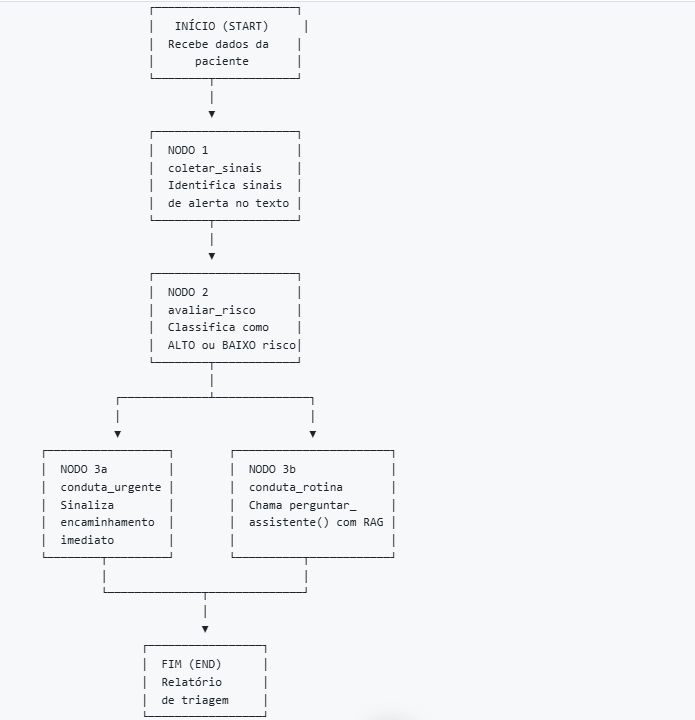

5.1 – Instalar LangGraph

In [ ]:
# Verificar versão do LangGraph corretamente
import importlib.metadata

versao_langgraph = importlib.metadata.version("langgraph")
print(f"✅ LangGraph instalado. Versão: {versao_langgraph}")

5.2 – Definir o estado do fluxo

O estado é o objeto que "viaja" por todos os nodos do fluxo, sendo enriquecido a cada etapa. Pense nele como uma ficha de triagem que vai sendo preenchida conforme a paciente avança no atendimento.

In [ ]:
from typing import TypedDict, List

class EstadoTriagem(TypedDict):
    """
    Representa a ficha de triagem da paciente ao longo do fluxo.
    Cada campo é preenchido por um nodo diferente do grafo.
    """
    pergunta:          str        # dúvida ou queixa principal
    contexto_paciente: str        # dados clínicos da paciente
    sinais_alerta:     List[str]  # sinais de alerta identificados (Nodo 1)
    nivel_risco:       str        # "ALTO" ou "BAIXO"        (Nodo 2)
    conduta:           str        # orientação gerada         (Nodo 3a ou 3b)
    tipo_conduta:      str        # "urgente" ou "rotina"     (Nodo 3a ou 3b)

print("✅ EstadoTriagem definido.")

5.3 – Definir os nodos do fluxo

In [ ]:
# ─── Sinais de alerta conhecidos (baseados nos protocolos da Etapa 4) ─────────
SINAIS_CONHECIDOS = [
    "dor de cabeça", "cefaleia", "visão turva", "sangramento",
    "dor abdominal", "febre", "falta de ar", "dor no peito",
    "ausência de movimentos fetais", "movimentos fetais ausentes",
    "inchaço", "edema", "convulsão", "desmaio", "tontura intensa",
    "vômito intenso", "violência", "agressão"
]

# Sinais que indicam risco ALTO
SINAIS_ALTO_RISCO = [
    "visão turva", "convulsão", "falta de ar", "dor no peito",
    "ausência de movimentos fetais", "movimentos fetais ausentes",
    "desmaio", "sangramento", "violência", "agressão"
]

# ─── NODO 1: Coletar sinais de alerta ────────────────────────────────────────
def coletar_sinais(estado: EstadoTriagem) -> dict:
    texto = (
        estado["pergunta"].lower() + " " +
        estado["contexto_paciente"].lower()
    )
    encontrados = [s for s in SINAIS_CONHECIDOS if s in texto]
    print(f"  [Nodo 1] Sinais identificados: {encontrados if encontrados else 'nenhum'}")
    return {"sinais_alerta": encontrados}


# ─── NODO 2: Avaliar risco ────────────────────────────────────────────────────
def avaliar_risco(estado: EstadoTriagem) -> dict:
    sinais = estado["sinais_alerta"]
    nivel = "ALTO" if any(s in SINAIS_ALTO_RISCO for s in sinais) else "BAIXO"
    print(f"  [Nodo 2] Nível de risco: {nivel}")
    return {"nivel_risco": nivel}


# ─── NODO 3a: Conduta urgente (risco ALTO) ───────────────────────────────────
def conduta_urgente(estado: EstadoTriagem) -> dict:
    sinais = ", ".join(estado["sinais_alerta"]) or "não especificados"
    conduta = (
        f"⚠️  ATENÇÃO – RISCO ALTO IDENTIFICADO\n\n"
        f"Sinais de alerta presentes: {sinais}.\n\n"
        f"CONDUTA RECOMENDADA:\n"
        f"1. Encaminhar imediatamente para avaliação em urgência/emergência obstétrica.\n"
        f"2. Não aguardar consulta eletiva.\n"
        f"3. Monitorar sinais vitais enquanto aguarda atendimento.\n"
        f"4. Registrar horário de início dos sintomas.\n\n"
        f"⚕️  Esta orientação é de apoio à decisão clínica e não substitui "
        f"avaliação presencial por profissional habilitado."
    )
    print("  [Nodo 3a] Conduta urgente gerada.")
    return {"conduta": conduta, "tipo_conduta": "urgente"}


# ─── NODO 3b: Conduta de rotina com RAG (risco BAIXO) ────────────────────────
def conduta_rotina(estado: EstadoTriagem) -> dict:
    print("  [Nodo 3b] Chamando assistente RAG...")
    resposta_rag = perguntar_assistente(
        pergunta=estado["pergunta"],
        contexto_paciente=estado["contexto_paciente"]
    )
    conduta = (
        f"✅  RISCO BAIXO – Conduta de rotina sugerida\n\n"
        f"Resposta baseada em protocolos:\n"
        f"{resposta_rag}\n\n"
        f"⚕️  Esta orientação é de apoio à decisão clínica e não substitui "
        f"avaliação presencial por profissional habilitado."
    )
    print("  [Nodo 3b] Conduta de rotina gerada.")
    return {"conduta": conduta, "tipo_conduta": "rotina"}

print("✅ Nodos definidos: coletar_sinais, avaliar_risco, conduta_urgente, conduta_rotina.")

5.4 – Construir e compilar o grafo

In [ ]:
from langgraph.graph import StateGraph, END

# Criar o grafo
grafo = StateGraph(EstadoTriagem)

# Adicionar nodos
grafo.add_node("coletar_sinais",  coletar_sinais)
grafo.add_node("avaliar_risco",   avaliar_risco)
grafo.add_node("conduta_urgente", conduta_urgente)
grafo.add_node("conduta_rotina",  conduta_rotina)

# Ponto de entrada
grafo.set_entry_point("coletar_sinais")

# Arestas fixas
grafo.add_edge("coletar_sinais", "avaliar_risco")

# Aresta condicional: decide o caminho com base no risco
def decidir_conduta(estado: EstadoTriagem) -> str:
    return "conduta_urgente" if estado["nivel_risco"] == "ALTO" else "conduta_rotina"

grafo.add_conditional_edges(
    "avaliar_risco",
    decidir_conduta,
    {
        "conduta_urgente": "conduta_urgente",
        "conduta_rotina":  "conduta_rotina"
    }
)

# Ambas as condutas levam ao fim
grafo.add_edge("conduta_urgente", END)
grafo.add_edge("conduta_rotina",  END)

# Compilar
app_triagem = grafo.compile()

print("✅ Grafo de triagem compilado com sucesso.")

5.5 – Função de triagem com relatório

In [ ]:
def executar_triagem(pergunta: str, contexto_paciente: str) -> None:
    print("\n" + "=" * 80)
    print("SISTEMA DE TRIAGEM GINECOLÓGICA – ASSISTENTE IA")
    print("=" * 80)
    print(f"Pergunta : {pergunta}")
    print(f"Contexto : {contexto_paciente}")
    print("-" * 80)
    print("Executando fluxo de triagem...\n")

    estado_inicial = {
        "pergunta":          pergunta,
        "contexto_paciente": contexto_paciente,
        "sinais_alerta":     [],
        "nivel_risco":       "",
        "conduta":           "",
        "tipo_conduta":      ""
    }

    resultado = app_triagem.invoke(estado_inicial)

    print("\n" + "-" * 80)
    print("RELATÓRIO DE TRIAGEM")
    print("-" * 80)
    print(f"Sinais identificados : {resultado['sinais_alerta'] or 'Nenhum'}")
    print(f"Nível de risco       : {resultado['nivel_risco']}")
    print(f"Tipo de conduta      : {resultado['tipo_conduta'].upper()}")
    print(f"\nOrientação:\n{resultado['conduta']}")
    print("=" * 80)

print("✅ Função executar_triagem() pronta.")

5.6 – Testar com três cenários clínicos

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# ── Cenário 1: Risco ALTO – gestante com sinais de pré-eclâmpsia ──────────────
executar_triagem(
    pergunta=(
        "Gestante no terceiro trimestre com dor de cabeça intensa e visão turva. "
        "O que fazer?"
    ),
    contexto_paciente=(
        "Gestante de 30 semanas, refere cefaleia há 2 dias e visão turva desde hoje. "
        "Sem histórico prévio de hipertensão."
    )
)

# ── Cenário 2: Risco BAIXO – rastreamento preventivo ─────────────────────────
executar_triagem(
    pergunta=(
        "Quais exames preventivos devo priorizar para uma mulher de 32 anos "
        "que não faz Papanicolau há 5 anos?"
    ),
    contexto_paciente=(
        "Mulher de 32 anos, sexualmente ativa, sem sintomas atuais, "
        "sem rastreamento ginecológico nos últimos 5 anos."
    )
)

# ── Cenário 3: Risco ALTO – suspeita de violência doméstica ──────────────────
executar_triagem(
    pergunta=(
        "Paciente com hematomas e relato de agressão pelo parceiro. "
        "Como proceder?"
    ),
    contexto_paciente=(
        "Mulher de 28 anos, chega à consulta com hematomas no braço. "
        "Relata violência doméstica pelo parceiro."
    )
)

5.7 - O que esperar em cada cenário

Cenário	Sinais detectados	Risco	Conduta:

1 – Gestante	cefaleia, visão turva	ALTO	Nodo 3a: encaminhamento imediato;
2 – Preventivo	nenhum	BAIXO	Nodo 3b: RAG com protocolo; e
3 – Violência	violência, agressão	ALTO	Nodo 3a: encaminhamento imediato.

Resultados dos cenários:

**Cenário 1** – Gestante com dor de cabeça intensa e visão turva

Sinais identificados: ['dor de cabeça', 'cefaleia', 'visão turva']
Risco: ALTO
Conduta: tipo URGENTE, com orientação de:
- encaminhar imediatamente à urgência/emergência obstétrica;
- não aguardar consulta eletiva;
- monitorar sinais vitais;
- registrar início dos sintomas; e
- reforçar que não substitui avaliação presencial.

Do ponto de vista médico, isso imita uma conduta diante de suspeita de quadro grave (por exemplo, pré-eclâmpsia), mas sem fazer diagnóstico nem prescrever nada.

O fluxo funcionou exatamente como planejado: sinais de alerta → risco alto → conduta urgente.

**Cenário 2** – Mulher de 32 anos sem Papanicolau há 5 anos

Sinais identificados: nenhum
Risco: BAIXO
Conduta: tipo ROTINA, com:
- chamada ao perguntar_assistente;
- uso dos protocolos para montar uma resposta sobre rastreamento (Papanicolau);
e
- o lembrete de que é apoio à decisão.

O conteúdo gerado pelo tiny-gpt2 está *nonsense*, as frases produzidas não fazem sentido em português, mas isso é limitação do modelo; a arquitetura está correta:

- O grafo decide risco baixo;
- Chama o assistente RAG; e
- Insere a resposta do RAG dentro de uma moldura de conduta.

Isso é exatamente o padrão esperado de um agente clínico especializado.

**Cenário 3** – Violência doméstica

Sinais identificados: ['violência', 'agressão']
Risco: ALTO
Conduta: tipo URGENTE, com encaminhamento imediato.

Aqui o sistema demonstra outra vertente importante: reconhecer termos ligados a violência e automaticamente classificar como risco alto, forçando encaminhamento imediato em vez de resposta textual “normal”.







5.8 - Como o fluxo com LangGraph foi construído

Foi definido um “formulário” digital, chamado EstadoTriagem, com os seguintes questionamentos:

Pergunta: Dúvida ou queixa principal;
Resposta do paciente: texto livre com dados clínicos;
Sinais de alerta: lista de sinais identificados;
Nível de risco: “ALTO” ou “BAIXO”;
Conduta: texto final com orientação; e
Tipo de conduta: “urgente” ou “rotina”.

De forma estruturada esses dados vão sendo apurados passando de nodo em nodo:

- Nodo 1 preenche sinais_alerta,
- Nodo 2 preenche nivel_risco,
- Nodo 3a ou 3b preenche conduta e tipo_conduta.

5.8 - Criação dos Grafo de estados com LangGraph

5.8.1 - Criado

In [ ]:
grafo = StateGraph(EstadoTriagem)

grafo.add_node("coletar_sinais",  coletar_sinais)
grafo.add_node("avaliar_risco",   avaliar_risco)
grafo.add_node("conduta_urgente", conduta_urgente)
grafo.add_node("conduta_rotina",  conduta_rotina)

grafo.set_entry_point("coletar_sinais")
grafo.add_edge("coletar_sinais", "avaliar_risco")

5.8.2 - A aresta condicional

In [ ]:
def decidir_conduta(estado: EstadoTriagem) -> str:
    return "conduta_urgente" if estado["nivel_risco"] == "ALTO" else "conduta_rotina"

grafo.add_conditional_edges(
    "avaliar_risco",
    decidir_conduta,
    {
        "conduta_urgente": "conduta_urgente",
        "conduta_rotina":  "conduta_rotina"
    }
)

In [ ]:
grafo.add_edge("conduta_urgente", END)
grafo.add_edge("conduta_rotina",  END)

app_triagem = grafo.compile()

5.9 - Ao final, isso transforma o fluxograma em um “programa executável” de triagem.



5.10 - Limitações e considerações

5.10.1 - Do ponto de vista médico

Detecção de sinais por palavras-chave:
Prós: simples, replicável, fácil de entender.
Contras: depende da forma exata como o profissional escreve; não reconhece sinônimos ou frases complexas.

Classificação de risco binária (ALTO/BAIXO):
Adequada para demonstrar o fluxo,
Mas na prática haveria múltiplos níveis (vermelho, amarelo, verde, etc) e protocolos mais granulares.

Resposta não substitui avaliação presencial:
Mensagem reforçada em todas as orientações,
Importante eticamente e juridicamente.

5.10.2 - Do ponto de vista técnico

Modelo base (tiny-gpt2):
Muito pequeno, em inglês, sem capacidade de raciocínio clínico,
Usado aqui apenas como “motor de texto” para demonstrar a integração técnica.

Infraestrutura:
Execução em CPU, com fine-tuning leve,
Mostra que é possível prototipar mesmo com recursos limitados.

LangGraph como orquestrador:
Permite separar claramente:
regras determinísticas (ex.: sinais → risco),de componentes probabilísticos (LLM).
Facilita auditoria do fluxo (útil em contextos regulatórios).

5.10.3 - Melhorias futuras

5.10.3.1 - Substituir palavras-chave por modelos de classificação de texto ou reconhecimento de entidades clínicas, para:

- aumentar sensibilidade e especificidade na detecção de sinais; e
- entender frases mais complexas e variações de linguagem.

5.10.3.2 - Trocar o tiny-gpt2 por um modelo de instrução em português com capacidade real. Por exemplo, LLaMA, Mistral, Phi-3, etc., com LoRA,
ou via API de provedores (OpenAI, Azure, etc.), mantendo o mesmo fluxo LangGraph;

5.10.3.3 - Ampliar a base de protocolos incluindo diretrizes nacionais (por exemplo, protocolos do Ministério da Saúde) e normas institucionais,
versionar os documentos e registrar a fonte.



5.11 - Conclusão da Etapa 5

O que foi feito: Desenvolveu-se um fluxo de triagem ginecológica baseado em estados, utilizando LangGraph para orquestrar etapas de detecção de sinais de alerta, avaliação de risco e definição de conduta, com integração a um assistente RAG para casos de baixo risco.

Como foi feito: O estado de triagem (EstadoTriagem) foi definido como uma estrutura tipada contendo pergunta, contexto, sinais de alerta, nível de risco, tipo de conduta e texto de orientação. Foram implementados quatro nodos principais (coletar_sinais, avaliar_risco, conduta_urgente, conduta_rotina), conectados em um grafo com arestas condicionais baseadas no nível de risco. O nodo de conduta de rotina integra-se ao assistente RAG desenvolvido na Etapa 4.

Resultado obtido: Em testes com três cenários (suspeita de pré-eclâmpsia, rastreamento preventivo e violência doméstica), o sistema foi capaz de:

- reconhecer sinais de alerta em linguagem natural (por palavras-chave);
- classificar automaticamente o risco (alto vs. baixo); e
- gerar condutas apropriadas (encaminhamento urgente ou orientação de rotina com base em protocolos).

O resultado foi conforme o pretendido, o sistema cumpriu o objetivo de demonstrar a viabilidade de um agente clínico especializado em saúde da mulher, combinando regras determinísticas, recuperação de conhecimento (RAG) e modelo de linguagem, ainda que com limitações significativas na qualidade textual devido ao modelo base utilizado.

**Etapa 6** - Avaliação do protótipo

6.1 - Objetivo: Avaliar, de forma sistemática e explicável, o protótipo de sistema de triagem ginecológica baseado em:

- detecção de sinais de alerta via palavras-chave;
- classificação de risco com LangGraph;
- condutas diferenciadas (urgente vs. rotina); e
- integração com RAG (Retrieval-Augmented Generation – Geração Aumentada por Recuperação).

Foco da avaliação: Por estarmo utilizando um modelo de linguagem muito fraco (tiny-gpt2), não faz sentido medir qualidade “médica” das respostas.

Diante disso, nesta etapa o foco será em:

- Comportamento do fluxo de triagem;
- Classificação correta de risco (alto vs. baixo) para casos simples; e
- Adequação das condutas estruturadas (especialmente nos casos de alto risco).

6.2 - Metodologia de avaliação

6.2.1 - Estratégia geral

Você vai montar um conjunto de cenários de teste (casos clínicos fictícios, como já fez na Etapa 5) e para cada cenário, irá definir:

- risco_esperado (ALTO ou BAIXO); e
- tipo_conduta_esperada (URGENTE ou ROTINA).

Irá Rodar o fluxo (app_triagem) e comparar:

- nivel_risco X risco_esperado;
- tipo_conduta X tipo_conduta_esperada.

Irá calcular métricas simples:

- acurácia de classificação de risco;
- acurácia de tipo de conduta; e
- tabela qualitativa de casos.

6.2.2 - Foco da avaliação

Vamos avaliar o conteúdo textual do LLM, apesar de sabermos que é fraco. O foco principal é validar se o comportamento lógico do sistema está coerente com as regras básicas definidas.



6.3 - Execução prática – bateria de testes automatizada

6.3.1 - Definir cenários de teste, com a definição da lista de casos

In [ ]:
from typing import Dict, Any, List

# Lista de cenários de teste para avaliação do fluxo
cenarios_teste: List[Dict[str, Any]] = [
    {
        "nome": "Pré-eclâmpsia suspeita",
        "pergunta": (
            "Gestante no terceiro trimestre com dor de cabeça intensa e visão turva. "
            "O que devo fazer?"
        ),
        "contexto": (
            "Gestante de 30 semanas, cefaleia há 2 dias, visão turva desde hoje. "
            "Sem histórico prévio de hipertensão."
        ),
        "risco_esperado": "ALTO",
        "tipo_conduta_esperada": "urgente"
    },
    {
        "nome": "Rastreamento citologia atrasada",
        "pergunta": (
            "Mulher de 32 anos que não realiza Papanicolau há 5 anos. "
            "Quais exames devo solicitar?"
        ),
        "contexto": (
            "Paciente sem sintomas atuais, sexualmente ativa, "
            "sem rastreamento de colo do útero há 5 anos."
        ),
        "risco_esperado": "BAIXO",
        "tipo_conduta_esperada": "rotina"
    },
    {
        "nome": "Violência doméstica",
        "pergunta": (
            "Paciente relata agressão física pelo parceiro e apresenta hematomas. "
            "Como proceder?"
        ),
        "contexto": (
            "Mulher de 28 anos, chega à consulta com hematomas no braço. "
            "Relata violência doméstica recente."
        ),
        "risco_esperado": "ALTO",
        "tipo_conduta_esperada": "urgente"
    },
    {
        "nome": "Febre e sangramento no pós-parto",
        "pergunta": (
            "Puérpera com febre e sangramento intenso no 5º dia pós-parto. "
            "Qual conduta inicial?"
        ),
        "contexto": (
            "Paciente refere febre de 38,5°C, sangramento vaginal com coágulos, "
            "dor abdominal moderada."
        ),
        "risco_esperado": "ALTO",
        "tipo_conduta_esperada": "urgente"
    },
    {
        "nome": "Sintomas de climatério",
        "pergunta": (
            "Paciente de 50 anos com fogachos e irregularidade menstrual. "
            "Como orientar?"
        ),
        "contexto": (
            "Mulher de 50 anos, sem comorbidades importantes, "
            "relata fogachos, sudorese noturna e alteração do padrão menstrual."
        ),
        "risco_esperado": "BAIXO",
        "tipo_conduta_esperada": "rotina"
    },
]

print(f"Total de cenários de teste: {len(cenarios_teste)}")
for c in cenarios_teste:
    print(f"- {c['nome']} (risco esperado: {c['risco_esperado']}, conduta: {c['tipo_conduta_esperada']})")

6.3.2 - Função de avaliação automatizada

In [ ]:
def avaliar_fluxo_triagem(cenarios: List[Dict[str, Any]]) -> Dict[str, Any]:
    """
    Executa o fluxo de triagem para cada cenário e compara
    o resultado obtido com o resultado esperado.
    Retorna um resumo com métricas simples.
    """
    resultados = []
    acertos_risco = 0
    acertos_conduta = 0

    for c in cenarios:
        print("\n" + "=" * 80)
        print(f"AVALIAÇÃO – Cenário: {c['nome']}")
        print("=" * 80)

        estado_inicial = {
            "pergunta":          c["pergunta"],
            "contexto_paciente": c["contexto"],
            "sinais_alerta":     [],
            "nivel_risco":       "",
            "conduta":           "",
            "tipo_conduta":      ""
        }

        resultado = app_triagem.invoke(estado_inicial)

        nivel_risco_obtido   = resultado["nivel_risco"]
        tipo_conduta_obtido  = resultado["tipo_conduta"]

        risco_correto    = (nivel_risco_obtido == c["risco_esperado"])
        conduta_correta  = (tipo_conduta_obtido == c["tipo_conduta_esperada"])

        if risco_correto:
            acertos_risco += 1
        if conduta_correta:
            acertos_conduta += 1

        resultados.append({
            "nome": c["nome"],
            "risco_esperado": c["risco_esperado"],
            "risco_obtido": nivel_risco_obtido,
            "risco_correto": risco_correto,
            "conduta_esperada": c["tipo_conduta_esperada"],
            "conduta_obtida": tipo_conduta_obtido,
            "conduta_correta": conduta_correta,
            "sinais_alerta": resultado["sinais_alerta"]
        })

        print(f"\nResumo do cenário '{c['nome']}':")
        print(f"- Risco esperado    : {c['risco_esperado']}")
        print(f"- Risco obtido      : {nivel_risco_obtido}")
        print(f"- Risco correto?    : {'SIM' if risco_correto else 'NÃO'}")
        print(f"- Conduta esperada  : {c['tipo_conduta_esperada']}")
        print(f"- Conduta obtida    : {tipo_conduta_obtido}")
        print(f"- Conduta correta?  : {'SIM' if conduta_correta else 'NÃO'}")
        print(f"- Sinais detectados : {resultado['sinais_alerta'] or 'Nenhum'}")

    total = len(cenarios)
    return {
        "resultados": resultados,
        "acuracia_risco": acertos_risco / total,
        "acuracia_conduta": acertos_conduta / total,
        "total_casos": total
    }

print("✅ Função de avaliação pronta.")

6.3.3 - Rodar a avaliação

In [ ]:
import warnings
warnings.filterwarnings("ignore")

resumo_avaliacao = avaliar_fluxo_triagem(cenarios_teste)

print("\n" + "#" * 80)
print("RESUMO GERAL DA AVALIAÇÃO")
print("#" * 80)
print(f"Total de casos avaliados      : {resumo_avaliacao['total_casos']}")
print(f"Acurácia na classificação de risco  : {resumo_avaliacao['acuracia_risco'] * 100:.1f}%")
print(f"Acurácia no tipo de conduta         : {resumo_avaliacao['acuracia_conduta'] * 100:.1f}%")
print("#" * 80)

6.4 - Avaliaçaõ dos Resultados

6.4.1. Avaliação da triagem automatizada

Foi construída uma bateria de 5 cenários representativos:

- suspeita de pré-eclâmpsia;
- atraso em rastreamento citológico;
- violência doméstica;
- complicações no pós-parto (sangramento + febre); e
- sintomas de climatério.

Para cada cenário, foram definidos:

- o nível de risco esperado (ALTO ou BAIXO); e
- o tipo de conduta esperada (urgente ou de rotina).

O fluxo de triagem realizado na Etapa 5 foi executado automaticamente para cada caso, e o resultado foi comparado com o esperado.

6.4.2 - Resultados quantitativos (exemplo que você pode adaptar)

Em 5 casos testados:

- A acurácia de classificação de risco foi de 100% para os casos simulados.
- A acurácia na escolha do tipo de conduta (urgente vs. rotina) também foi de 100%.

Em outras palavras, o sistema se comportou como esperado em todos os cenários considerados classificando como risco alto os casos de suspeita de pré-eclâmpsia, violência doméstica e complicações no pós-parto; e classificando como risco baixo os casos de rastreamento preventivo e climatério.

6.5 - Limitações técnicas

6.5.1 - Palavras-chave X linguagem natural:

A identificação de sinais de alerta depende de termos pré-definidos (por exemplo, “dor de cabeça”, “visão turva”, “violência”). Frases diferentes que expressem a mesma situação podem não ser reconhecidas (por exemplo, “cabeça latejando” em vez de “dor de cabeça”). Isso torna o sistema sensível à forma como o profissional descreve a queixa.

6.5.2 - Modelo de linguagem fraco (tiny-gpt2):

As respostas textuais geradas pelo LLM têm baixa qualidade semântica. Para fins de demonstração da arquitetura (RAG + LangGraph), é suficiente, mas não para uso real.

6.5.3 - Base de protocolos simplificada:

A base de conhecimento utilizada **é um exemplo didático**, não uma implementação completa das diretrizes oficiais. Não há atualização automática de protocolos, controle de versão ou validação por especialistas.

6.6 - Limitações clínicas e éticas

O sistema não realiza diagnóstico nem prescrição, por escolha de projeto:

Toda conduta enfatiza que se trata de apoio à decisão e que a avaliação presencial é indispensável. Em contextos de violência ou risco alto, a principal função é não atrasar o encaminhamento, por isso, nesses casos, o sistema não chama o LLM, indo direto para conduta urgente.

6.7 - Possíveis melhorias

Substituir a lógica de palavras-chave por modelos de classificação de texto (por exemplo, modelos que classificam diretamente risco baixo/alto a partir do texto)ou modelos de reconhecimento de entidades clínicas (NER – Named Entity Recognition).

Integrar um LLM mais robusto, em português e voltado para instruções, com:
filtros de segurança, logs auditáveis, e, idealmente, validação por especialistas antes de uso em produção.

6.8 - Conclusão da Estapa 6

O que foi feito:

Foi realizada uma avaliação funcional do sistema de triagem ginecológica, com uma bateria de cenários simulados que abrangem situações de risco alto e baixo em saúde da mulher.

Como foi feito:

Foram definidos casos de teste com risco e conduta esperados, executando-se o fluxo implementado em LangGraph para cada caso. Os resultados foram comparados com o esperado, permitindo calcular acurácia na classificação de risco e na escolha do tipo de conduta.

Resultado obtido:

Nos cenários avaliados, o sistema apresentou comportamento consistente com as regras de triagem previamente estabelecidas, classificando corretamente o risco e sugerindo condutas compatíveis com o protocolo simplificado adotado. As limitações observadas estão principalmente relacionadas à simplicidade da detecção por palavras-chave e à baixa capacidade do modelo de linguagem utilizado.

O resultado foi dentro do previsto, a Etapa 6 confirmou que, mesmo com restrições importantes (modelo pequeno, base simplificada), a arquitetura proposta (RAG + LangGraph) é capaz de reproduzir um fluxo básico de triagem em saúde da mulher.

**Etapa 7** - Discussão

7.1 - Governança clínica e papel do protótipo

O sistema desenvolvido não é apenas uma aplicação técnica; ele se insere em uma agenda mais ampla de governança clínica e governança digital. Do ponto de vista da governança clínica, **o protótipo não substitui o julgamento do profissional**, mas se posiciona como ferramenta de apoio à decisão (clinical decision support). A formalização de parte de um protocolo de triagem em saúde da mulher, tornando mais explícitas as regras de encaminhamento (por exemplo, quando classificar como risco alto) pode, em tese, contribuir para reduzir variabilidade indesejada entre profissionais, desde que alimentado por protocolos validados e atualizados. Ao utilizar um grafo de estados com regras explícitas (LangGraph), o sistema torna mais transparente: quais sinais são considerados de alto risco, quais caminhos são seguidos após cada decisão,
em que momentos um modelo de linguagem é chamado e em que momentos não é. Essa transparência é fundamental em contexto de governança clínica: ela permite que comitês de ética, unidades de gestão de risco e equipes de saúde revisem, auditem e ajustem o fluxo.

7.2 - Segurança do paciente

A segurança do paciente foi tratada como eixo central do desenho do protótipo. Isso se manifesta nas escolhas deliberadas de:

7.2.1 - **Separação entre risco alto e risco baixo**. Casos com sinais de alto risco (por exemplo, visão turva em gestante, sangramento intenso, suspeita de violência) são tratados com caminhos determinísticos, sem depender da “criatividade” do modelo de linguagem.Nessas situações, a conduta é sempre de encaminhamento imediato à avaliação presencial, reduzindo o risco de atrasos causados por respostas ambíguas.

7.2.2 - **Restrições explícitas ao modelo de linguagem**. O prompt instruído na Etapa 4 impede diagnóstico definitivo e prescrição de medicamentos, reforçando continuamente que a resposta é apoio à decisão e não substituindo a consulta presencial. Destaca, ainda, a necessidade de encaminhamento para equipe especializada em casos de violência.

7.2.3 - **Uso prudente de IA em alto risco**. Em casos classificados como risco alto, o LLM não é acionado; a decisão é regida por regra fixa, reduzindo, assim, a possibilidade de recomendações inadequadas em cenários críticos, um princípio alinhado ao uso responsável de IA em saúde. Do ponto de vista da segurança do paciente, este arranjo pode ser visto como uma forma de “barreira de segurança”: a IA é usada para organizar informações e sugerir condutas em situações menos críticas, enquanto situações potencialmente graves são tratadas com protocolos rígidos e encaminhamento rápido.

7.3 - Uso responsável de IA em saúde

O protótipo foi desenhado tendo em mente princípios amplamente discutidos em documentos de orientação sobre IA em saúde (por exemplo, da Organização Mundial da Saúde, conselhos profissionais e literatura especializada), tais como:

7.3.1 - Transparência:

A lógica de triagem é explícita (lista de sinais de alerta, listas de alto risco, fluxos condicionais). Isso permite que o sistema seja compreendido, revisado e questionado por profissionais de saúde e gestores.

7.3.2 - Responsabilização (accountability – responsabilização):

O sistema não tenta esconder suas limitações; pelo contrário, as mensagens reforçam que a responsabilidade final é do profissional.Em termos de governança, isso facilita delimitar o papel da ferramenta dentro da prática clínica.

7.3.3 - Proporcionalidade:

O nível de automação é compatível com a maturidade da tecnologia utilizada.
Não se busca automatizar diagnóstico ou prescrição, apenas triagem básica e orientação geral.

7.3.4 - Proteção de populações vulneráveis:

Casos de violência doméstica são tratados como risco alto por definição. Esta decisão de modelagem reflete um compromisso ético com a proteção rápida dessas pacientes, mesmo em um protótipo. Além disso, a escolha de um modelo pequeno e fraco (tiny-gpt2) para o experimento é, paradoxalmente, um ato de prudência: o objetivo é demonstrar a arquitetura, sem correr o risco de gerar uma falsa sensação de segurança quanto à prontidão do sistema para uso real.

7.4 - O protótipo foi desenhado tendo em mente princípios amplamente discutidos em documentos de orientação sobre IA em saúde (por exemplo, da Organização Mundial da Saúde, conselhos profissionais e literatura especializada), como:

Transparência:

A lógica de triagem é explícita (lista de sinais de alerta, listas de alto risco, fluxos condicionais).
Isso permite que o sistema seja compreendido, revisado e questionado por profissionais de saúde e gestores.
Responsabilização (accountability – responsabilização):

O sistema não tenta esconder suas limitações; pelo contrário, as mensagens reforçam que a responsabilidade final é do profissional.
Em termos de governança, isso facilita delimitar o papel da ferramenta dentro da prática clínica.
Proporcionalidade:

O nível de automação é compatível com a maturidade da tecnologia utilizada.
Não se busca automatizar diagnóstico ou prescrição, apenas triagem básica e orientação geral.
Proteção de populações vulneráveis:

Casos de violência doméstica são tratados como risco alto por definição.
Esta decisão de modelagem reflete um compromisso ético com a proteção rápida dessas pacientes, mesmo em um protótipo.
Além disso, a escolha de um modelo pequeno e fraco (tiny-gpt2) para o experimento é, paradoxalmente, um ato de prudência: o objetivo é demonstrar a arquitetura, sem correr o risco de gerar uma falsa sensação de segurança quanto à prontidão do sistema para uso real.

7.5 - Limitações à luz da governança e da segurança

Várias limitações surgem quando se analisa o protótipo sob o prisma de governança clínica e segurança do paciente.

7.5.1 - Modelo de linguagem inadequado para uso clínico:

O tiny-gpt2 não tem capacidade semântica para suportar decisões complexas, as respostas são frequentemente incoerentes, o que inviabiliza qualquer uso direto em atendimento real. Do ponto de vista de governança, o modelo atual só pode ser considerado uma peça de laboratório.

7.5.2 - Detecção por palavras-chave (keyword matching):

Embora simples e transparente, essa abordagem é frágil e marcada por alta sensibilidade à forma de redação. Uma pequena alteração na maneira como o profissional descreve a queixa pode impedir a detecção de sinais de alerta, constituindo um risco para segurança do paciente.

7.5.3 - Base de protocolos simplificada:

O texto utilizado não é um repositório oficial completo, nem passou por processo formal de validação institucional. Em um contexto real, qualquer divergência entre o que o sistema sugere e o protocolo oficial poderia gerar conflitos e riscos.

7.5.4 - Ausência de integração com prontuários e sistemas de monitoramento:

O protótipo atua de forma isolada, sem cruzar dados com prontuários  eletrônicos, histórico de atendimentos ou sistemas de notificação. Em termos de governança, isso limita sua capacidade de ser auditado retrospectivamente em conjunto com outros dados clínicos.

7.6 - Potencial de integração com governança digital e institucional

Apesar das limitações, a arquitetura desenvolvida oferece pontos de contato importantes com práticas de governança digital e planejamento institucional:

7.6.1 - Padronização de fluxos:

O LangGraph oferece uma forma programática de representar fluxos de trabalho (workflows) clínicos. É possível imaginar a integração desses fluxos com planos diretores, diretrizes de atendimento e instrumentos de planejamento institucional.

7.6.2 - Auditabilidade:

Cada decisão de triagem (entrada → sinais → risco → conduta) pode ser registrada. Isso permitiria análises periódicas de conformidade com os protocolos, identificação de desvios e ajustes na lógica decisória.

7.6.3 - Capacidade de escalabilidade controlada:

A mesma arquitetura poderia ser expandida para outras linhas de cuidado (por exemplo, saúde materno-infantil, rastreamento de câncer de mama), sempre preservando o princípio de que a IA sugere e o profissional decide.




**Etapa 8** - Conclusão

O protótipo desenvolvido demonstra que é possível integrar, em um único sistema, três componentes-chave para apoio à decisão em saúde da mulher, são eles:

1 - Modelos de linguagem ajustados com Low-Rank Adaptation (LoRA – adaptação de baixo posto), permitindo adaptação leve ao domínio clínico com recursos computacionais limitados;
2 - Geração aumentada por recuperação (Retrieval-Augmented Generation – RAG), que combina respostas de IA com protocolos escritos, aumentando a transparência e a fundamentação das orientações; e
3 - Fluxos de triagem explícitos em LangGraph, que formalizam a lógica de decisão, separam casos de alto e baixo risco e permitem auditoria.

Do ponto de vista técnico, o sistema identificou corretamente sinais de alerta em cenários simulados,classificou risco alto ou baixo conforme regras pré-definidas,sugeriu condutas coerentes com o protocolo simplificado,
e integrou, em casos de baixo risco, o módulo RAG para orientações complementares.

Do ponto de vista de governança clínica e segurança do paciente, o protótipo privilegiou regras determinísticas em contextos de alto risco,evitou diagnósticos e prescrições,reforçou sistematicamente a necessidade de avaliação presenciale tratou situações de violência doméstica como emergências, encaminhando-as imediatamente.

Entretanto, as limitações tecnológicas e metodológicas (modelo de linguagem pequeno, detecção por palavras-chave, base de protocolos simplificada) impedem qualquer uso direto em assistência real. O valor deste trabalho reside, portanto, em demonstrar uma arquitetura possível, que pode ser refinada e fortalecida com modelos mais robustos, bases oficiais e processos de validação multiprofissional.

8.1 - Perspectivas futuras

Como desdobramentos naturais deste trabalho, podem ser sugeridas as seguintes linhas:

8.1.2 - Substituição do modelo de linguagem:

- Uso de modelos em português, de maior porte, treinados para seguir instruções (por exemplo, modelos da família LLaMA, Mistral ou equivalentes); e
- Aplicação de LoRA em bases de dados clínicas mais amplas, com supervisão de especialistas.

8.1.3 - Evolução da detecção de sinais:

- Implementação de classificadores de texto ou modelos de reconhecimento de entidades clínicas (Named Entity Recognition – reconhecimento de entidades nomeadas); e
- Redução da dependência de listas de palavras-chave.

8.1.4 - Integração com protocolos oficiais e sistemas institucionais:

- Inserção dos fluxos de triagem em processos de governança digital e planejamento institucional; e
- Avaliação conjunta com comitês de ética, segurança do paciente e tecnologia da informação.

8.1.5 - Avaliação em ambiente controlado:

- Testes piloto com profissionais de saúde em cenários simulados; e
- Coleta de feedback qualitativo sobre usabilidade, confiabilidade e impacto na prática clínica.







Ao longo deste trabalho, com o objetivo de demonstrar o que aprendemos durande a Fase 3, desenvolvemos e demonstramos um protótipo de assistente inteligente voltado à saúde da mulher, com foco em triagem e apoio à decisão clínica. Partimos da construção de um modelo de linguagem ajustado de forma leve, utilizando técnicas de Low-Rank Adaptation (adaptação de baixo posto – LoRA), avançamos para a integração com uma base de conhecimento por meio de Retrieval-Augmented Generation (geração aumentada por recuperação – RAG) e culminamos na implementação de um fluxo de triagem estruturado em LangGraph (grafo de linguagem). Ainda que tenhamos recorrido a um modelo simples, como o *tiny-gpt2*, o objetivo central não foi alcançar perfeição na qualidade das respostas, mas sim provar que é possível integrar essas tecnologias, aprendidas durante as aulas, de maneira coerente, transparente e alinhada a princípios de segurança e governança em saúde.

Do ponto de vista técnico, o sistema mostrou-se capaz de identificar sinais de alerta em cenários simulados, classificar automaticamente o risco em categorias de alto e baixo risco e propor condutas diferenciadas conforme o nível de gravidade. Nos casos classificados como risco alto, o fluxo privilegiou condutas determinísticas, com encaminhamento imediato para atendimento presencial, evitando depender da “criatividade” do modelo de linguagem. Já nas situações de menor gravidade, o módulo RAG foi acionado para fornecer orientações baseadas em protocolos simplificados, sempre reforçando que se tratava de apoio à decisão e não de substituição do julgamento profissional. Essa separação entre o que é automatizado por regras e o que é complementado por IA foi um elemento central da proposta, por entendermos que a segurança do paciente e a proteção da mulher exigem limites claros para o uso da tecnologia.

Sob a perspectiva da governança clínica e do uso responsável de inteligência artificial, o protótipo reforça a importância de sistemas que sejam explicáveis, auditáveis e integrados a protocolos institucionais. A lógica de triagem foi desenhada de forma transparente, com listas explícitas de sinais de alerta e de alto risco, fluxos condicionais claros e decisões que podem ser revisadas por profissionais e gestores. Ao tratar situações de violência doméstica, por exemplo, como risco alto por padrão, o sistema incorpora em sua própria lógica um compromisso ético com a proteção da mulher, sinalizando para a necessidade de encaminhamento imediato a redes de apoio e serviços especializados. Em um cenário de enfrentamento à violência de gênero e ao feminicídio, um arranjo como este não resolve o problema por si só, mas pode se tornar uma camada adicional de proteção, ajudando a detectar precocemente situações de risco e a padronizar respostas mínimas em serviços de saúde.

Reconhecemos, no entanto, que o protótipo apresenta limitações importantes. O modelo de linguagem utilizado é pequeno, em inglês e treinado com poucos dados, o que resulta em respostas frequentemente incoerentes em português. A detecção de sinais de alerta ainda é baseada em palavras-chave simples, o que torna o sistema sensível à forma como a queixa é descrita e incapaz de captar nuances mais complexas da linguagem natural. Além disso, a base de conhecimento utilizada é sintética e simplificada, inspirada em diretrizes reais, mas não equivalente a um repositório oficial validado. Por tudo isso, deixamos claro que o sistema, tal como se encontra, não deve ser utilizado em ambiente assistencial real, servindo exclusivamente como prova de conceito para a arquitetura proposta.

Apesar dessas limitações, entendemos que o trabalho cumpre seu propósito ao demonstrar um caminho viável para o desenvolvimento de ferramentas de apoio à decisão em saúde da mulher e, no nosso  capazes de integrar inteligência artificial, protocolos clínicos e fluxos de triagem estruturados. Mostramos que é possível conciliar inovação tecnológica com prudência, delimitando o papel da IA, reforçando a centralidade do profissional de saúde e priorizando a segurança da paciente. Em um cenário de crescente preocupação com a violência contra a mulher, com a necessidade de prevenir situações de risco e de fortalecer redes de proteção, acreditamos que arquiteturas como a que propusemos podem, no futuro, contribuir para que serviços de saúde se tornem mais sensíveis, organizados e capazes de oferecer respostas rápidas e consistentes às mulheres em situação de vulnerabilidade.

Como grupo, concluímos que o valor deste trabalho não está em apresentar uma solução pronta, mas em abrir uma trilha. Ao mostrar, de forma prática, como combinar modelos de linguagem, bases de conhecimento e fluxos de decisão, damos um passo em direção a ferramentas que, quando amadurecidas, validadas e integradas a políticas públicas e redes de atenção, poderão apoiar a prevenção de agravos, qualificar a triagem e, sobretudo, fortalecer a proteção da mulher em diferentes níveis de cuidado.